In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mlp
import math
import scipy
from sklearn.neighbors import LocalOutlierFactor

In [2]:
# Loading the data
df = pd.read_pickle("../../data/interim/01_data_processed.pkl")

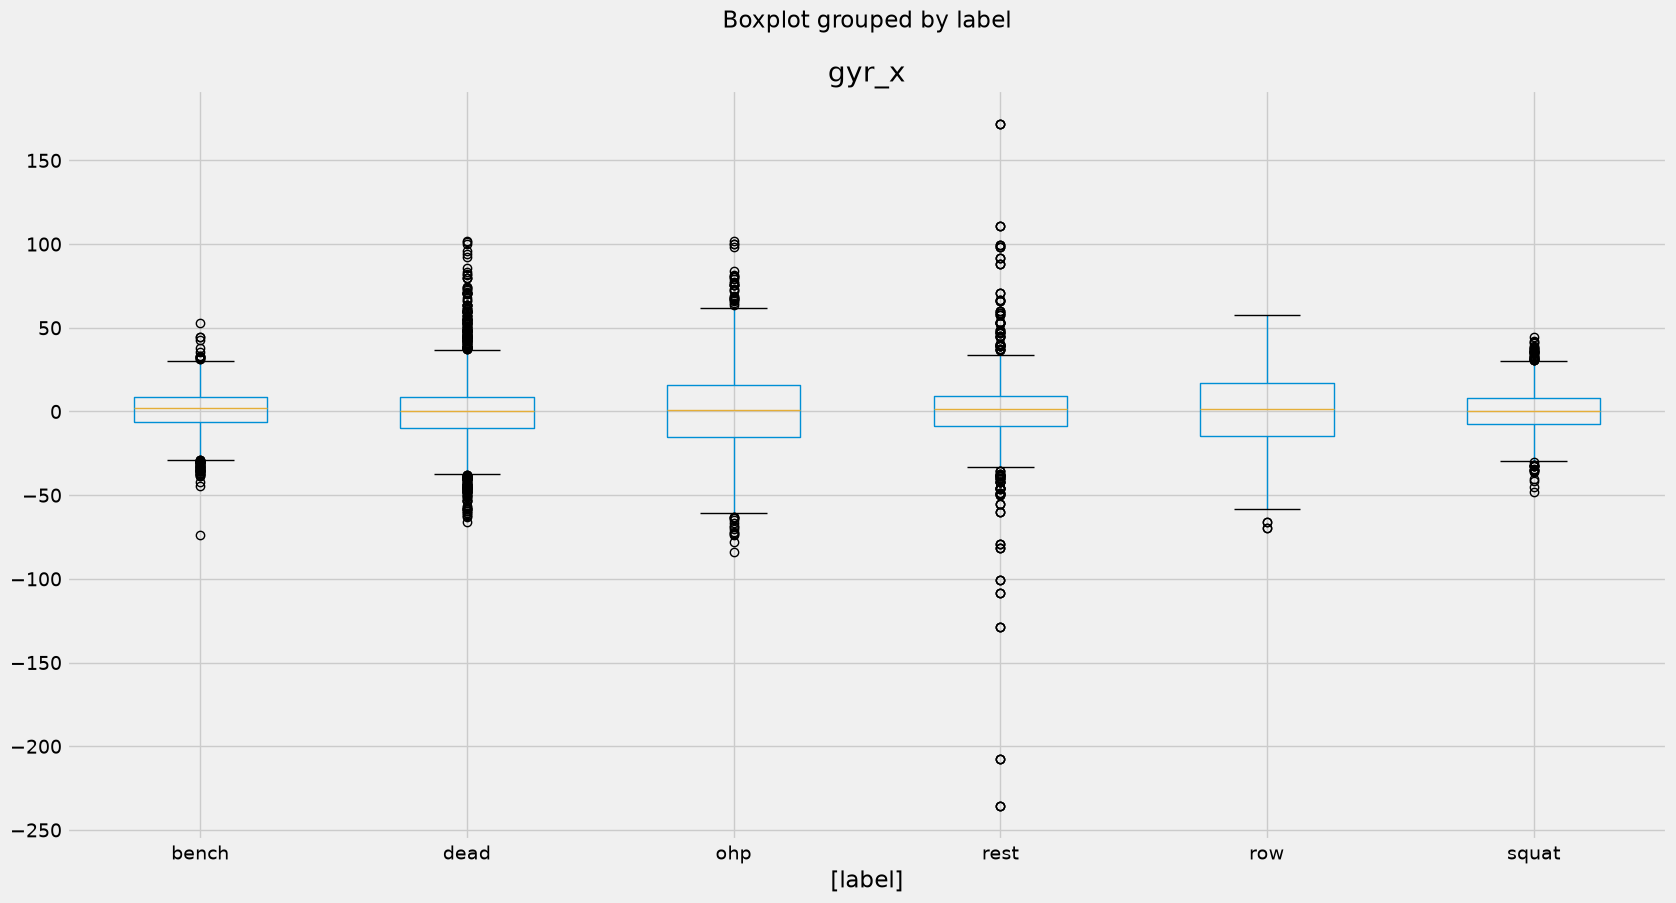

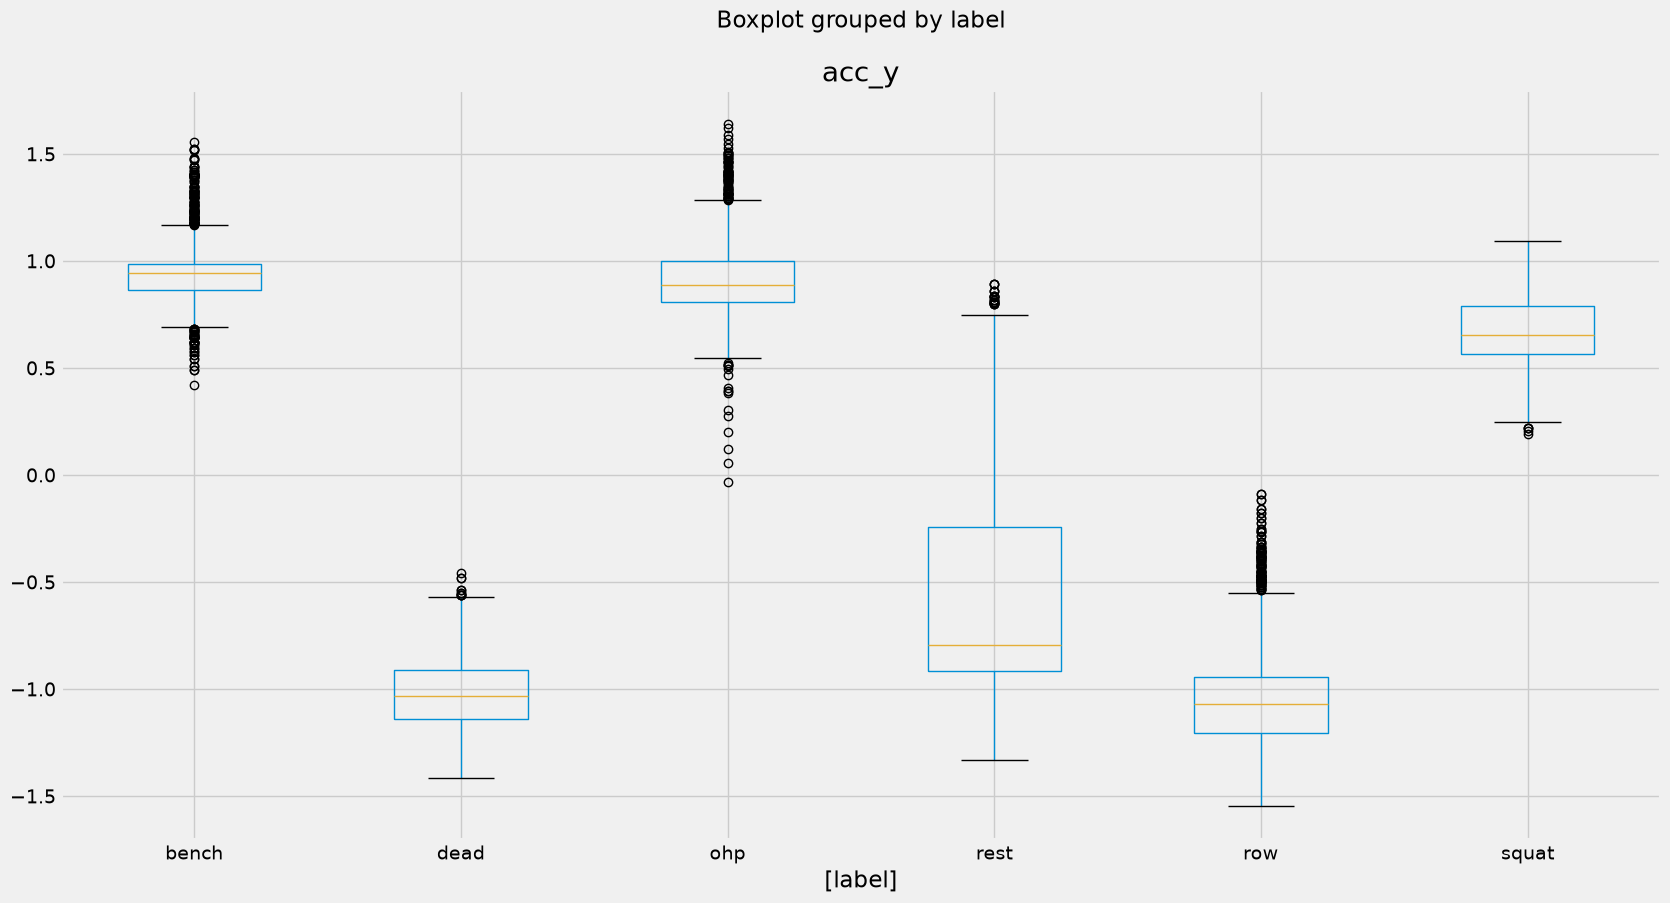

In [3]:
#Plotting the outliers

#first create the styling for the plots

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20,5)
plt.rcParams["figure.dpi"] = 100

df[["gyr_x", "label"]].boxplot(by="label", figsize=(20,10))
df[["acc_y", "label"]].boxplot(by="label", figsize=(20,10))
plt.show()

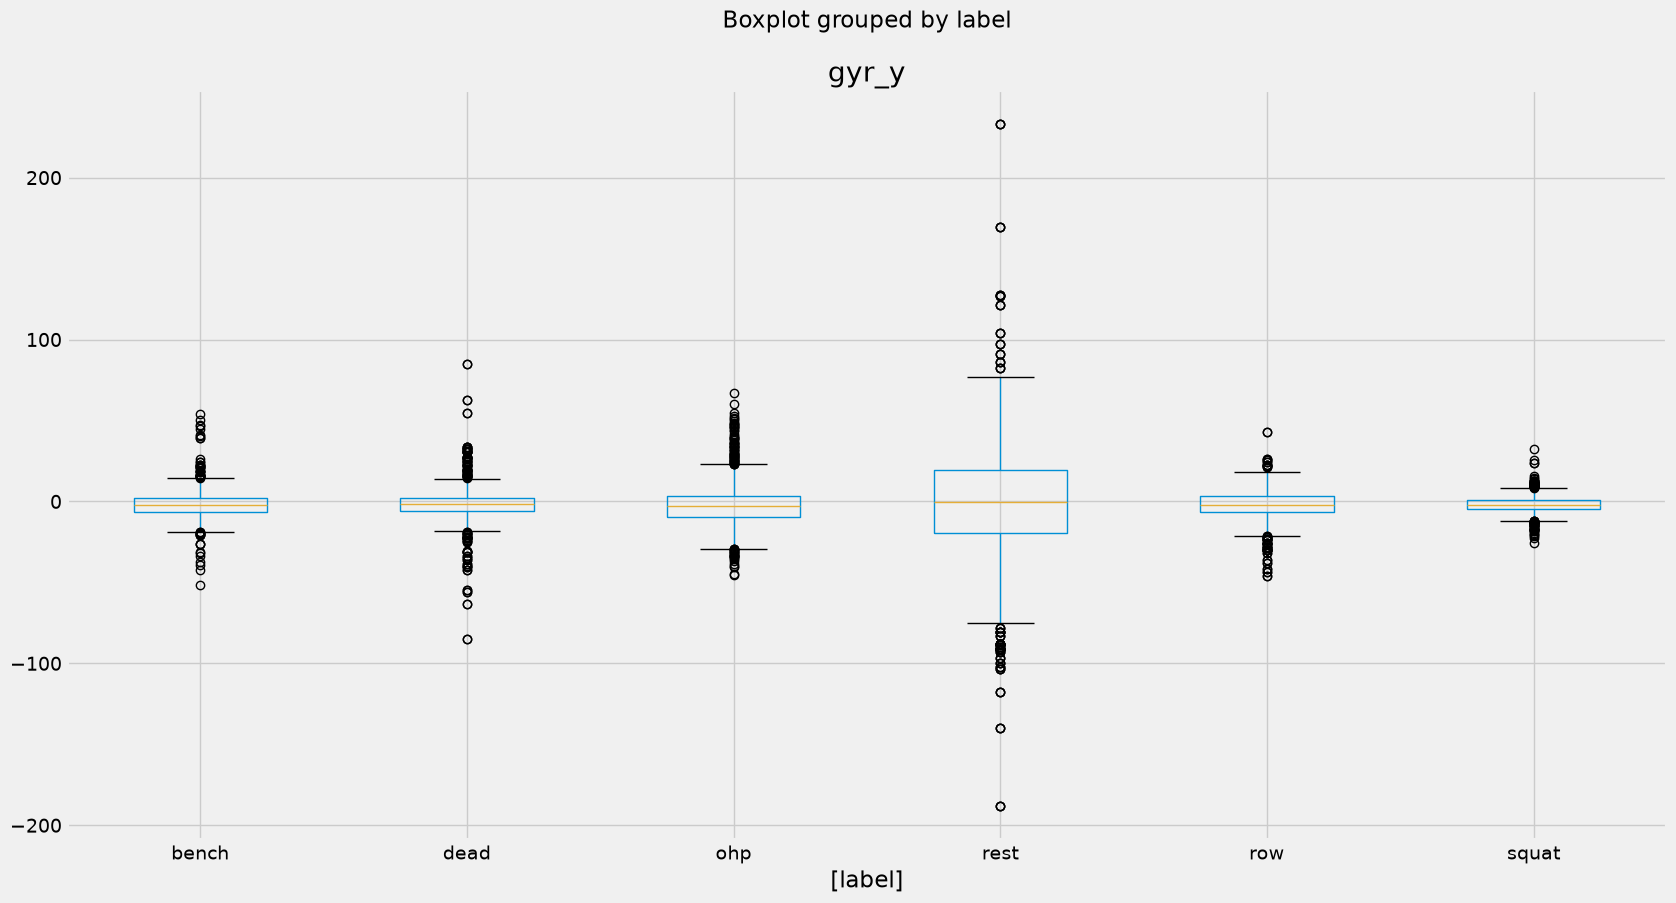

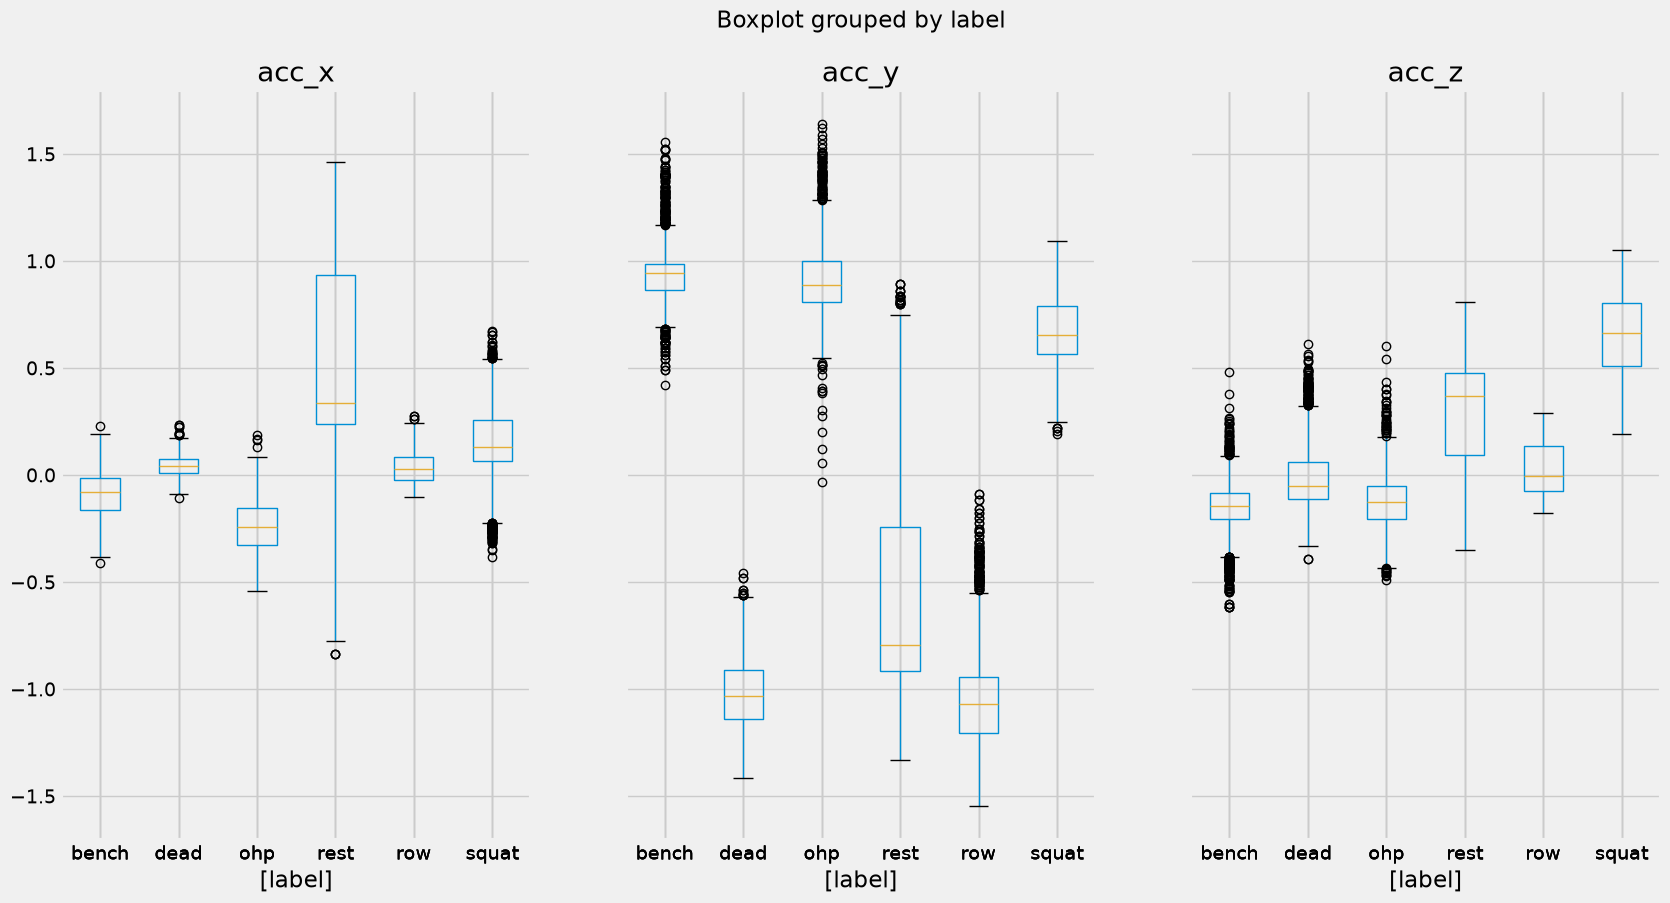

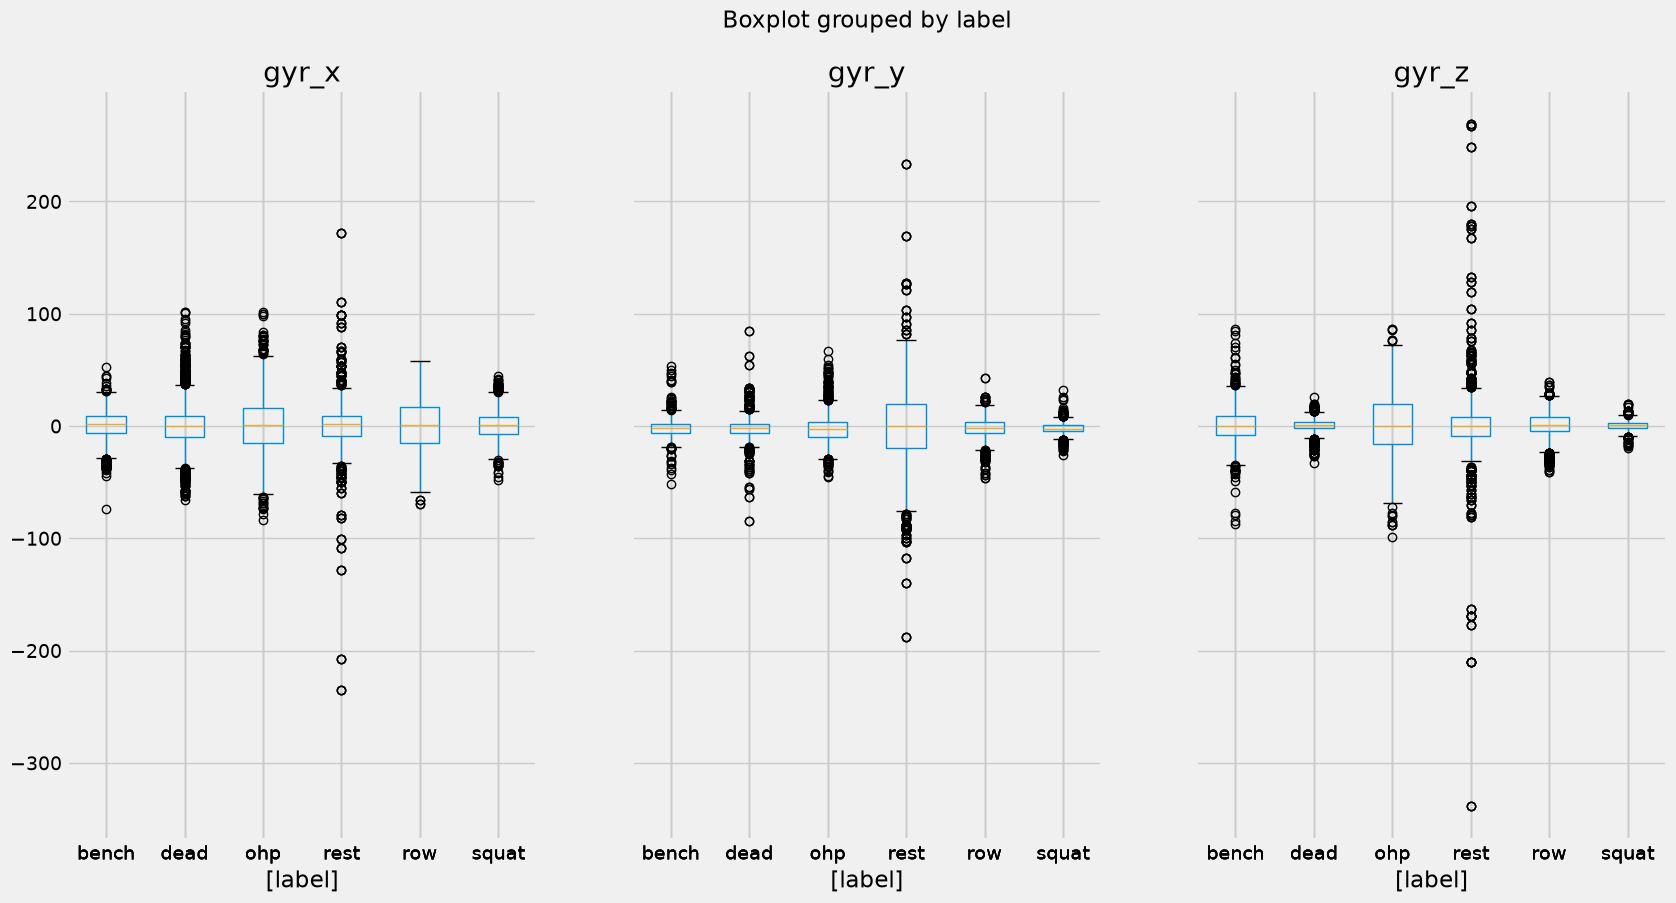

In [7]:
#We have to check the outliers of all numeric colomns

outliers_columns = list(df.columns[:6])

plt.style.use("fivethirtyeight")
plt.rcParams["figure.figsize"] = (20,5)
plt.rcParams["figure.dpi"] = 100

df[["gyr_y", "label"]].boxplot(by="label", figsize=(20,10))

df[outliers_columns[:3] + ["label"]].boxplot(by="label", figsize=(20,10), layout = (1,3))
df[outliers_columns[3:] + ["label"]].boxplot(by="label", figsize=(20,10), layout = (1,3))

plt.show()

In [10]:
# Create custom function to outlier chart 

def plot_binary_outliers(dataset, col, outlier_col, reset_index):
    """ Plot outliers in case of a binary outlier score. Here, the col specifies the real data
    column and outlier_col the columns with a binary value (outlier or not).

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): Column that you want to plot
        outlier_col (string): Outlier column marked with true/false
        reset_index (bool): whether to reset the index for plotting
    """

    # Taken from: https://github.com/mhoogen/ML4QS/blob/master/Python3Code/util/VisualizeDataset.py

    dataset = dataset.dropna(axis=0, subset=[col, outlier_col])
    dataset[outlier_col] = dataset[outlier_col].astype("bool")

    if reset_index:
        dataset = dataset.reset_index()

    fig, ax = plt.subplots()

    plt.xlabel("samples")
    plt.ylabel("value")

    # Plot non outliers in default color
    ax.plot(
        dataset.index[~dataset[outlier_col]],
        dataset[col][~dataset[outlier_col]],
        "+",
    )
    # Plot data points that are outliers in red
    ax.plot(
        dataset.index[dataset[outlier_col]],
        dataset[col][dataset[outlier_col]],
        "r+",
    )

    plt.legend(
        ["outlier " + col, "no outlier " + col],
        loc="upper center",
        ncol=2,
        fancybox=True,
        shadow=True,
    )
    plt.show()
    

In [11]:
#Marking outliers using IQR

def mark_outliers_iqr(dataset, col):
    """Function to mark values as outliers using the IQR method.

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to

    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column 
        indicating whether the value is an outlier or not.
    """

    dataset = dataset.copy()

    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    dataset[col + "_outlier"] = (dataset[col] < lower_bound) | (
        dataset[col] > upper_bound
    )

    return dataset

## Ploting the outliers using visual

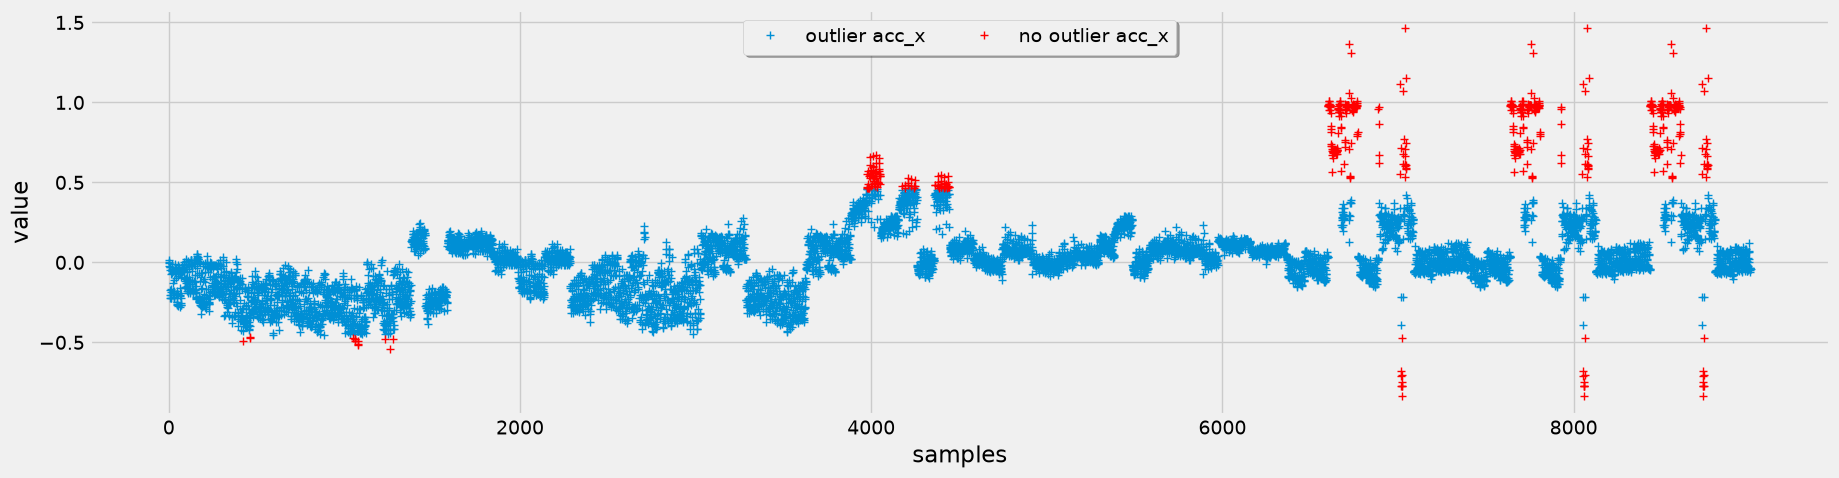

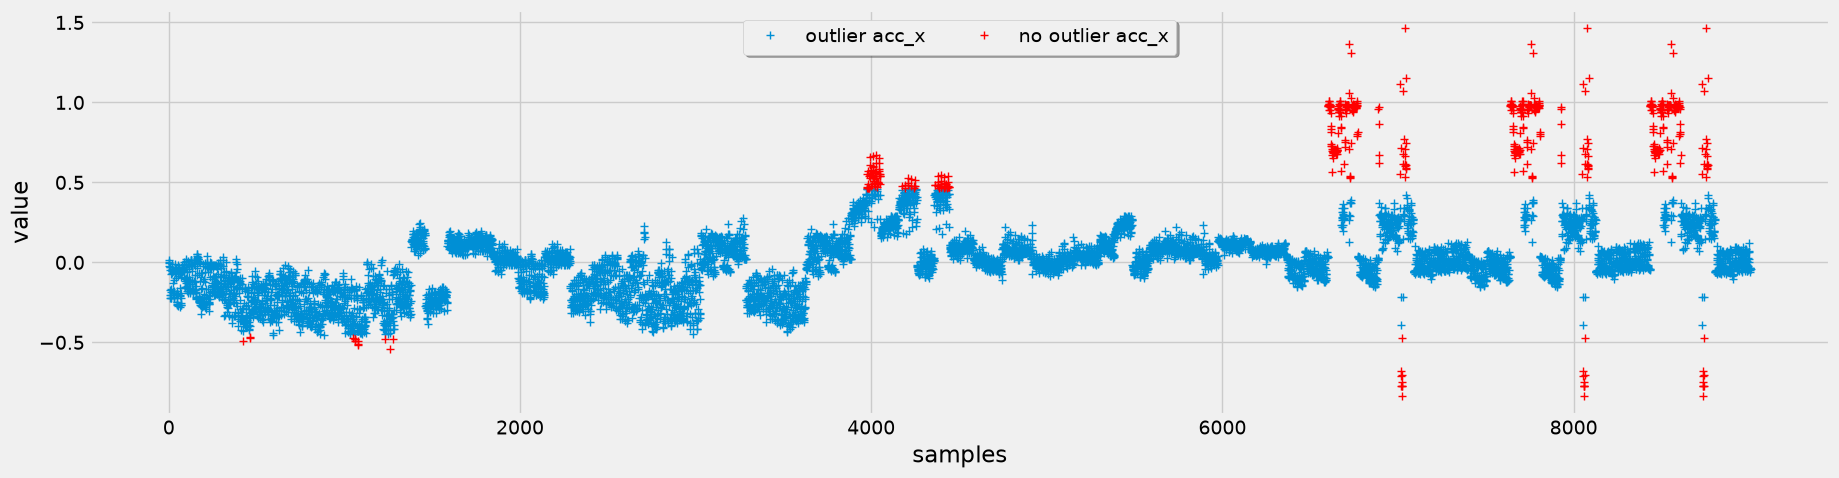

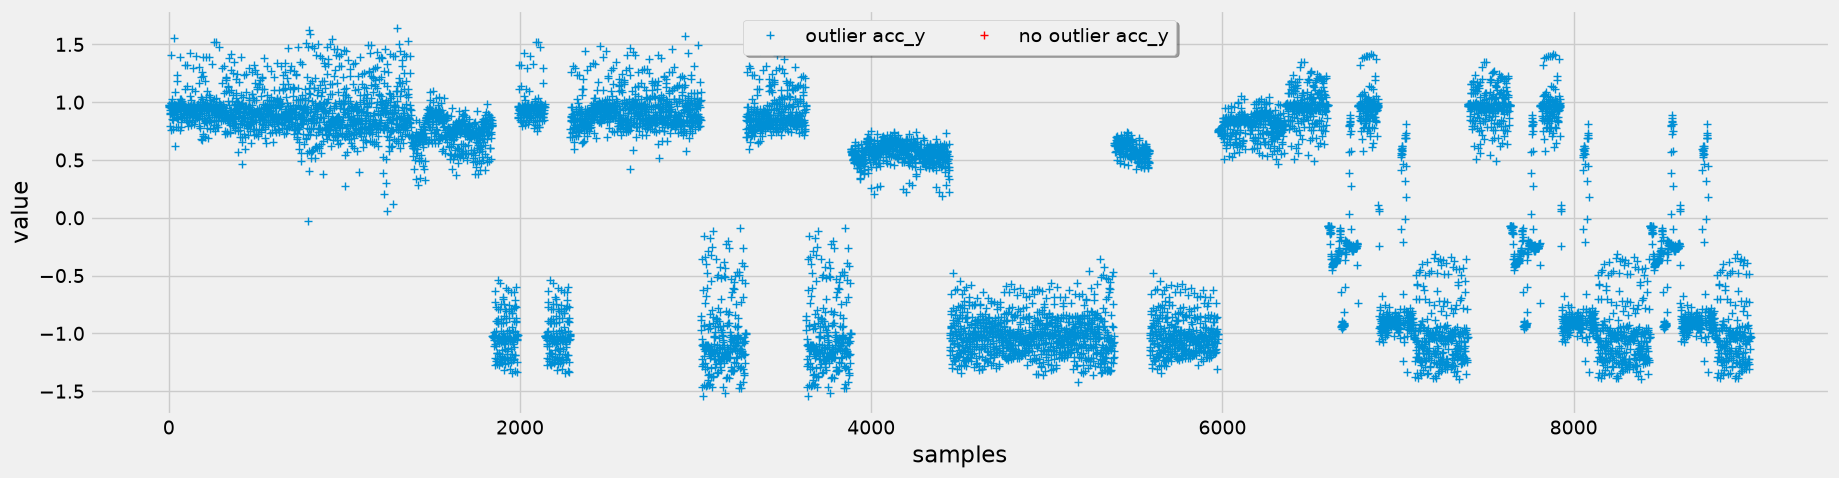

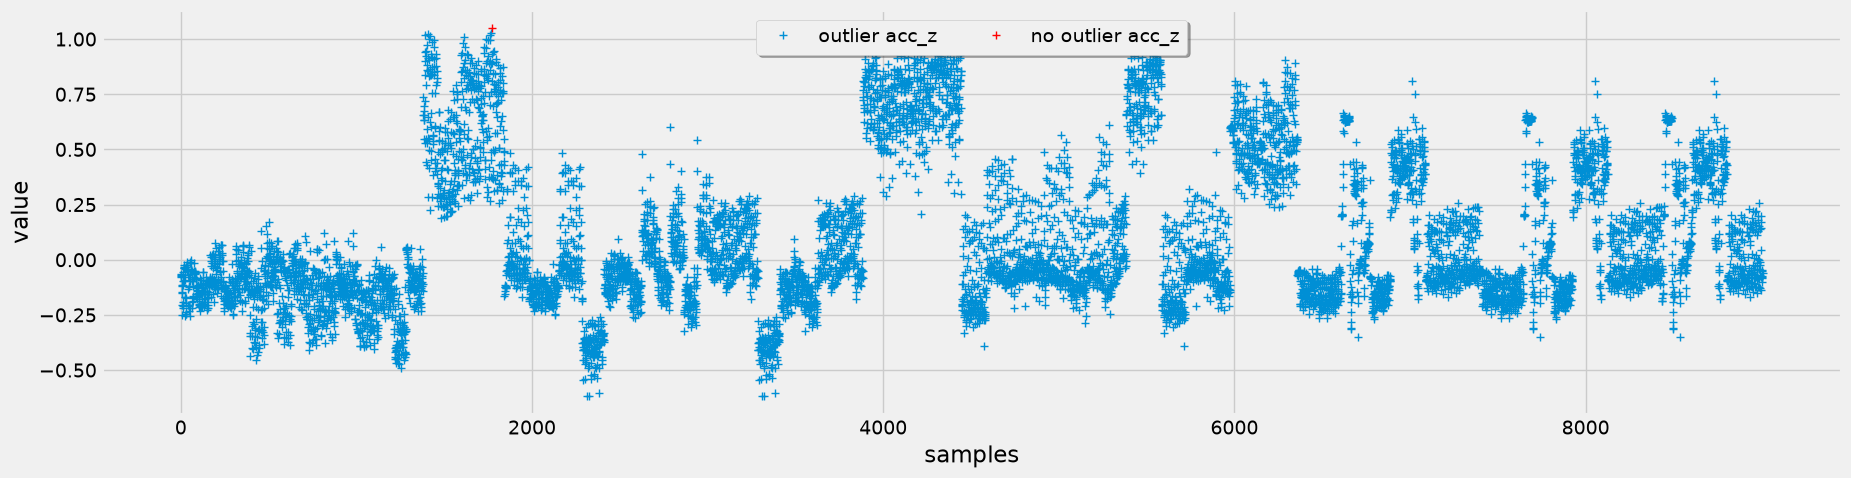

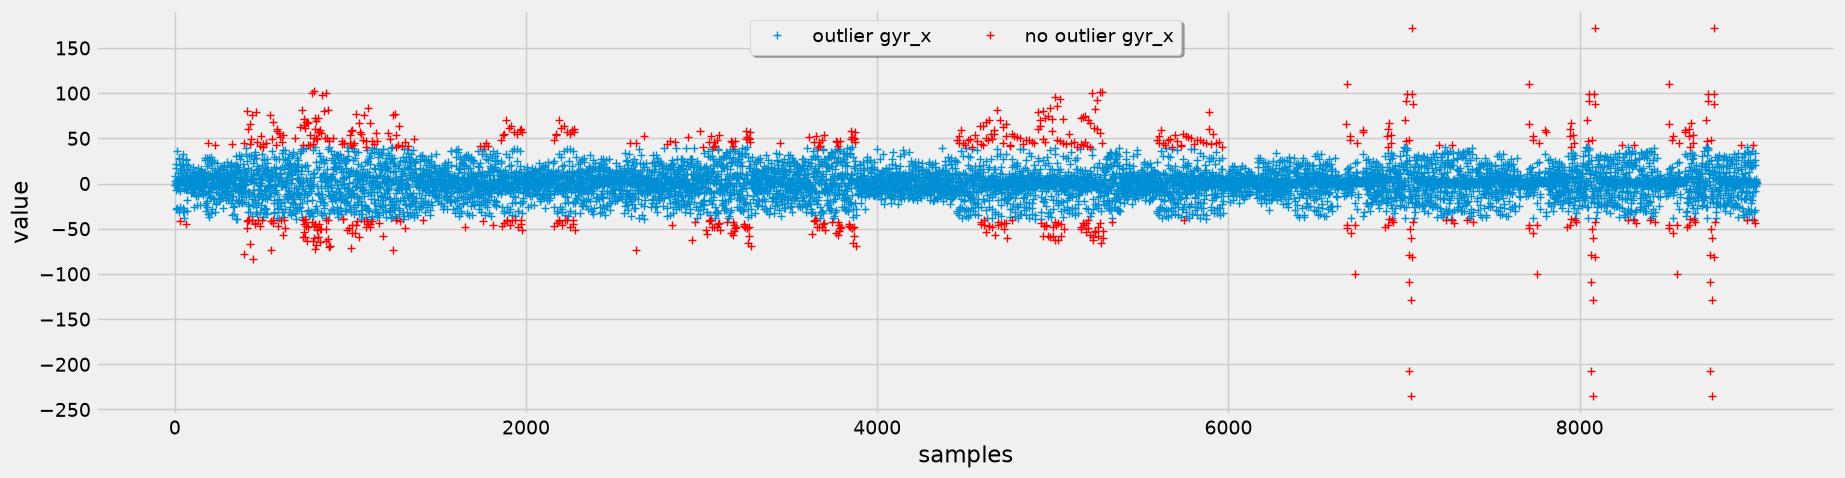

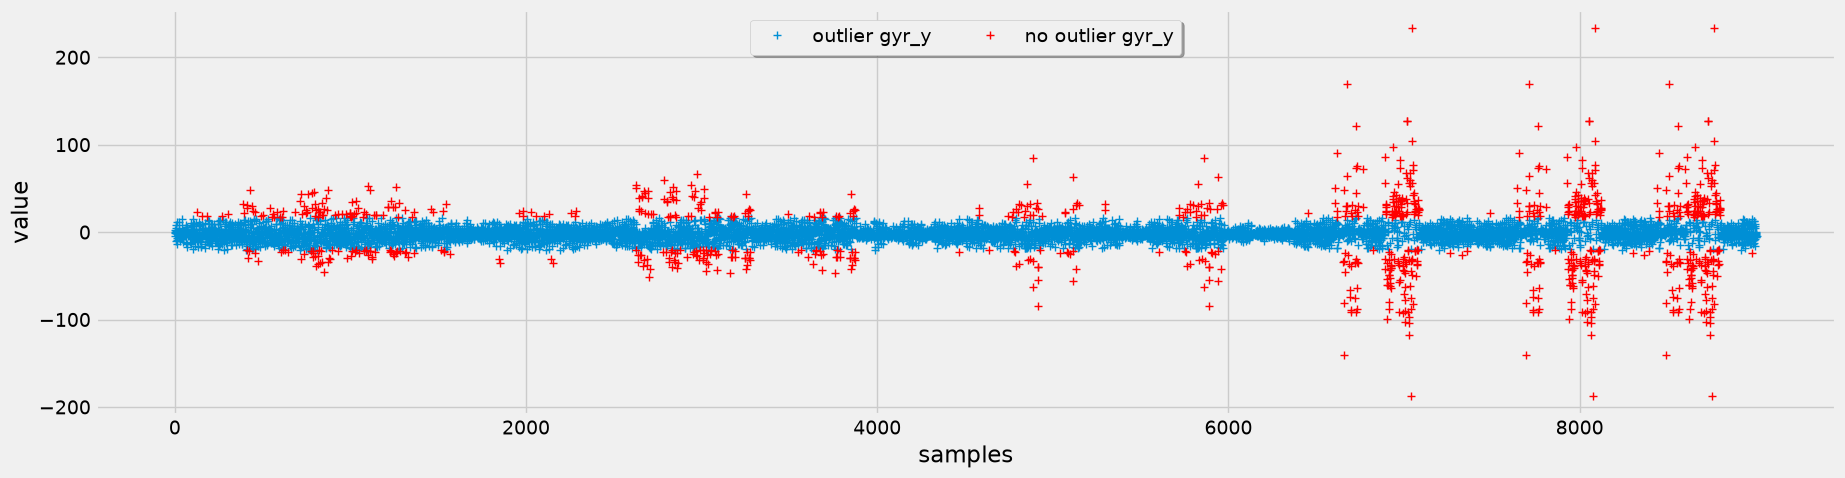

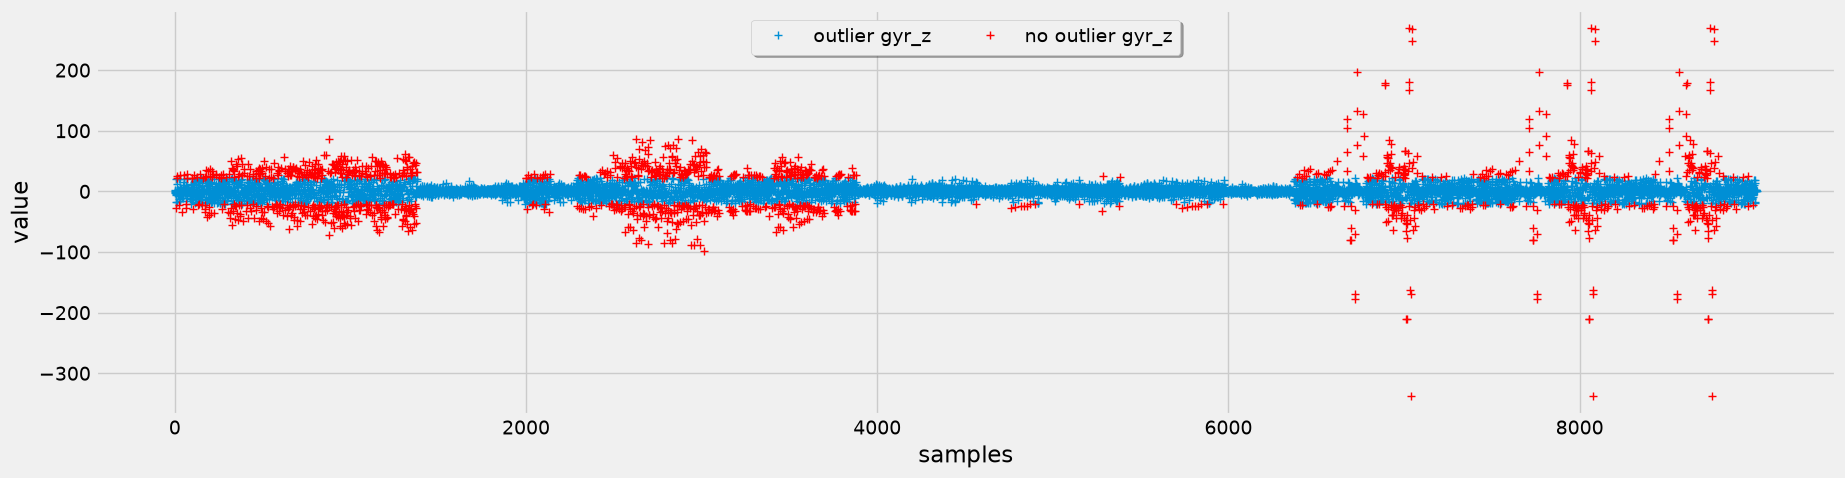

In [20]:
#Ploting the outliers using visual
col = "acc_x"
dataset = mark_outliers_iqr(df,col)
plot_binary_outliers(dataset=dataset, col=col, outlier_col=col+"_outlier", reset_index=True)


#Loop over all columns

for col in outliers_columns:
    dataset = mark_outliers_iqr(df,col)
    plot_binary_outliers(dataset=dataset, col=col, outlier_col=col+"_outlier", reset_index=True)


array([[<Axes: title={'center': 'bench'}, ylabel='Frequency'>,
        <Axes: title={'center': 'dead'}, ylabel='Frequency'>,
        <Axes: title={'center': 'ohp'}, ylabel='Frequency'>],
       [<Axes: title={'center': 'rest'}, ylabel='Frequency'>,
        <Axes: title={'center': 'row'}, ylabel='Frequency'>,
        <Axes: title={'center': 'squat'}, ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>]], dtype=object)

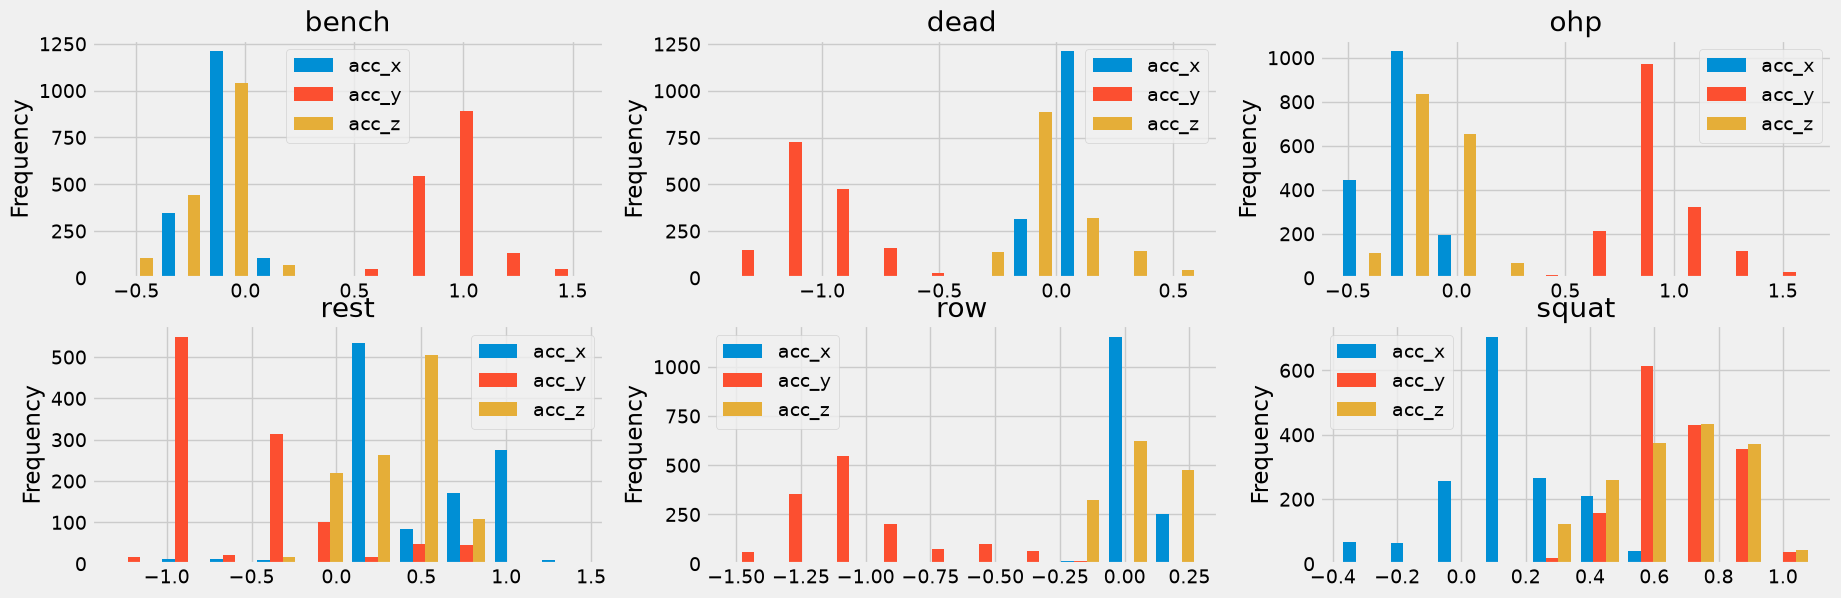

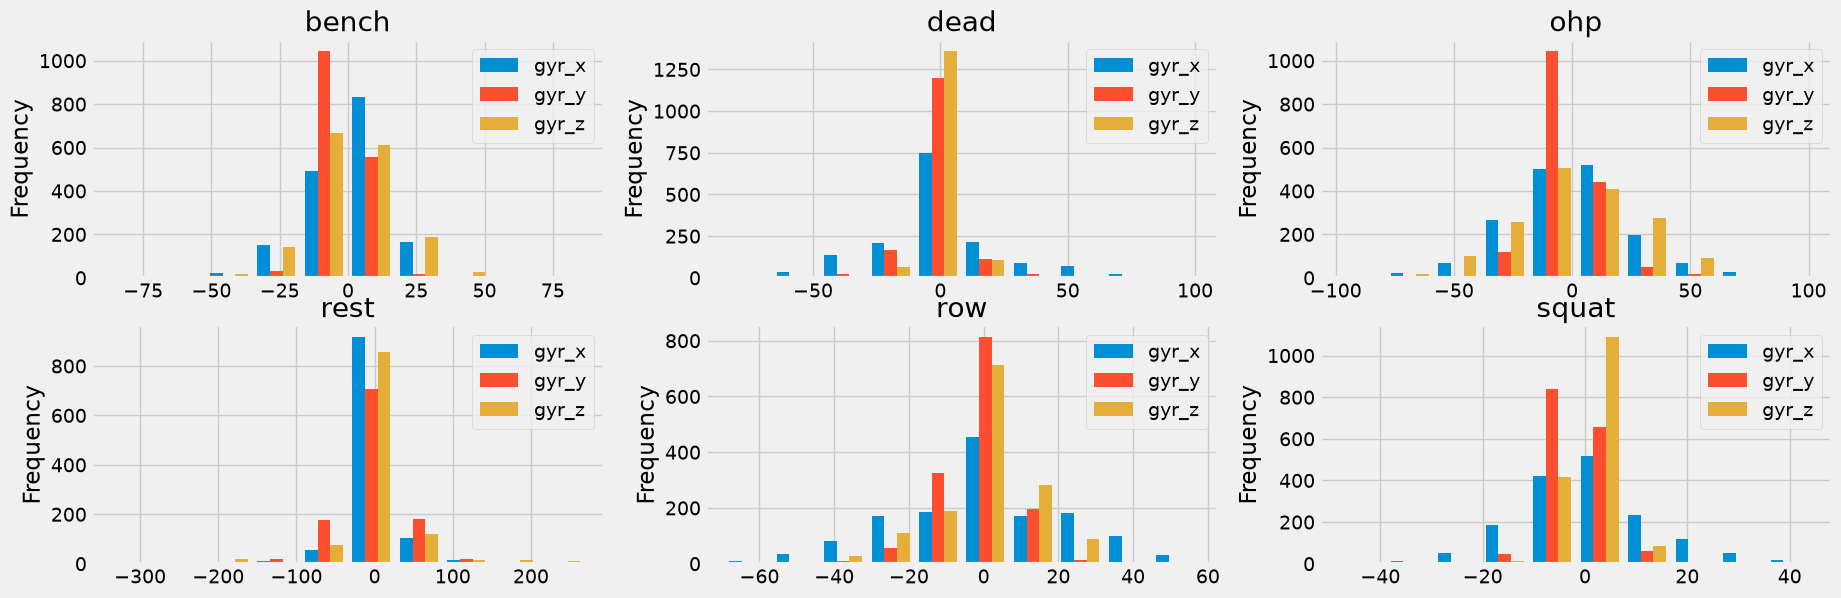

In [22]:
#Check the Data before using the chauvenents criteron

''' Before inserting the Chauvenets Criteron to check the Outlier in the Data we have to consider the following conditions
    - Normal distribution :It's important to note that Chauvenet's criterion is only applicable to datasets that are normally distributed. 
    - If your dataset is not normally distributed, this method may not be suitable for identifying outliers.
        - Histogram — Do you see a bell shaped curve?
        - Boxplot — Is the box symmetrical?
'''


#Creating hisogram to check the outlier_colomns

df[outliers_columns[:3] + ["label"]].plot.hist(by="label", figsize=(20,10), layout = (3,3))
df[outliers_columns[3:] + ["label"]].plot.hist(by="label", figsize=(20,10), layout = (3,3))


## Chauvenets Criteron (Distribution Based)

In [24]:
# Chauvenets Criteron (Distribution Based) for outlier detection

def mark_outliers_chauvenet(dataset, col, C=2):
    """Finds outliers in the specified column of datatable and adds a binary column with
    the same name extended with '_outlier' that expresses the result per data point.
    
    Taken from: https://github.com/mhoogen/ML4QS/blob/master/Python3Code/Chapter3/OutlierDetection.py

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to
        C (int, optional): Degree of certainty for the identification of outliers given the assumption 
                           of a normal distribution, typicaly between 1 - 10. Defaults to 2.

    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column 
        indicating whether the value is an outlier or not.
    """

    dataset = dataset.copy()
    # Compute the mean and standard deviation.
    mean = dataset[col].mean()
    std = dataset[col].std()
    N = len(dataset.index)
    criterion = 1.0 / (C * N)

    # Consider the deviation for the data points.
    deviation = abs(dataset[col] - mean) / std

    # Express the upper and lower bounds.
    low = -deviation / math.sqrt(C)
    high = deviation / math.sqrt(C)
    prob = []
    mask = []

    # Pass all rows in the dataset.
    for i in range(0, len(dataset.index)):
        # Determine the probability of observing the point
        prob.append(
            1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
        )
        # And mark as an outlier when the probability is below our criterion.
        mask.append(prob[i] < criterion)
    dataset[col + "_outlier"] = mask
    return dataset

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


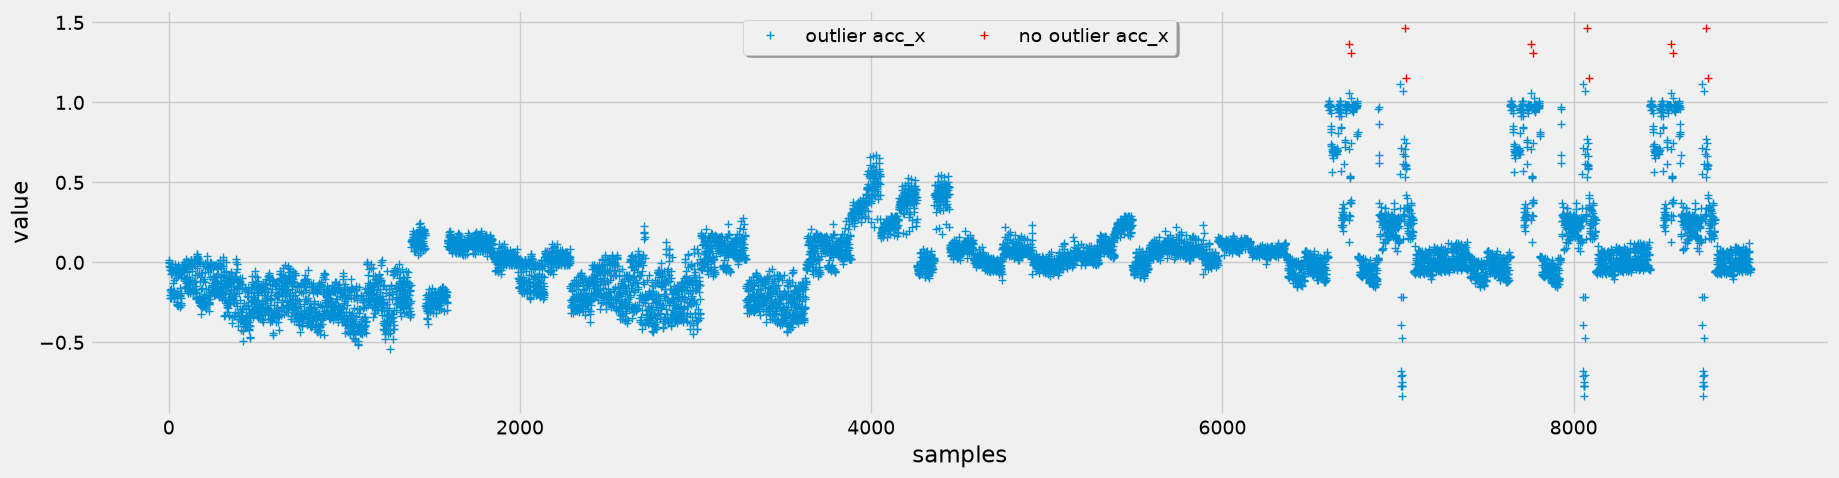

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


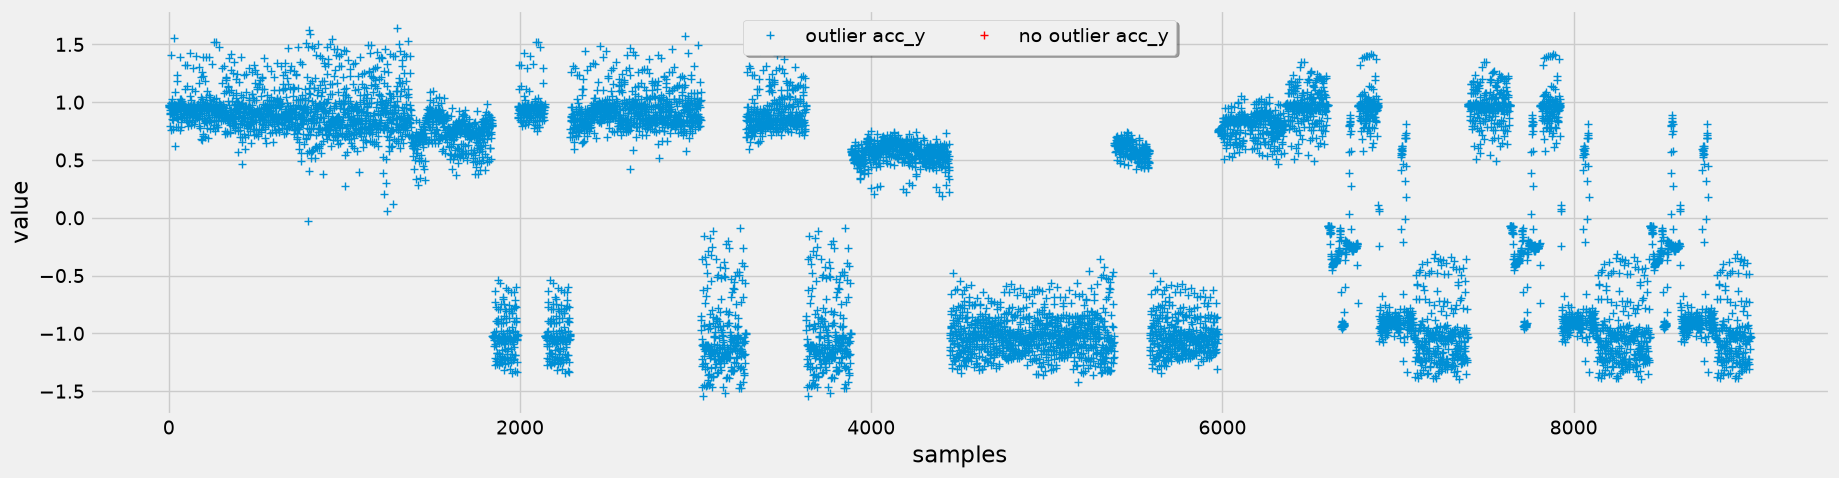

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


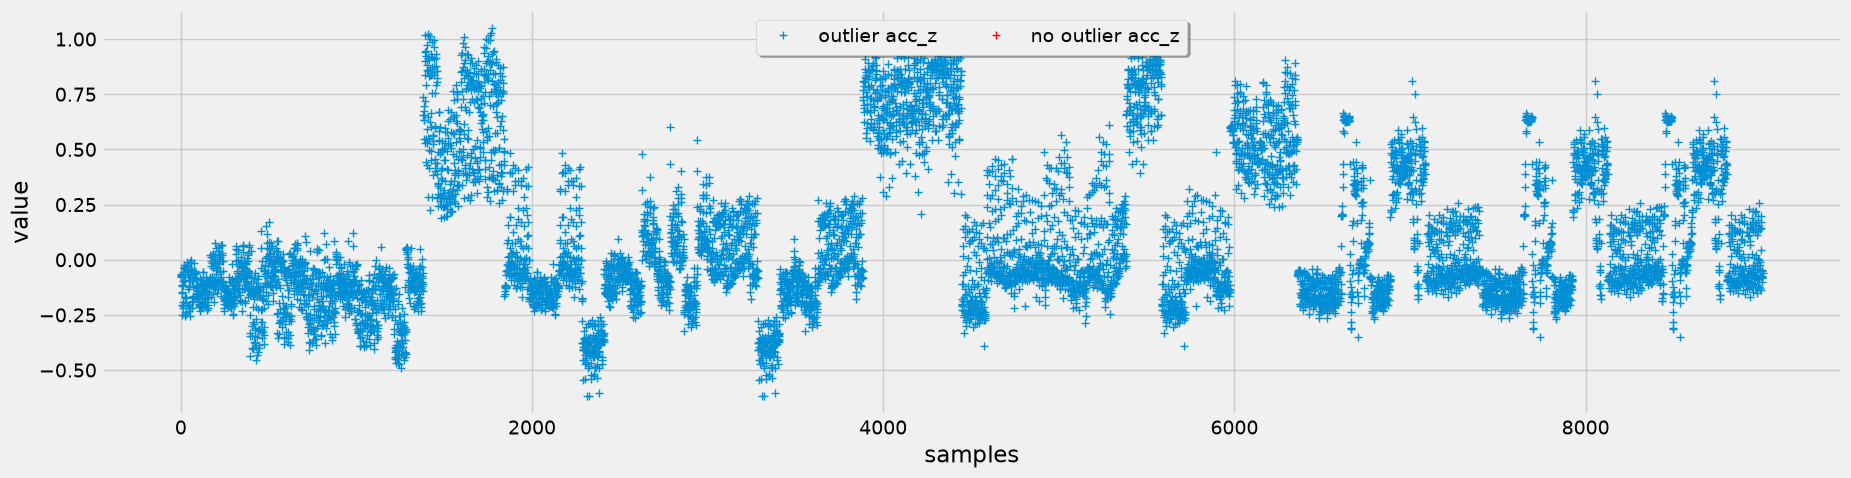

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


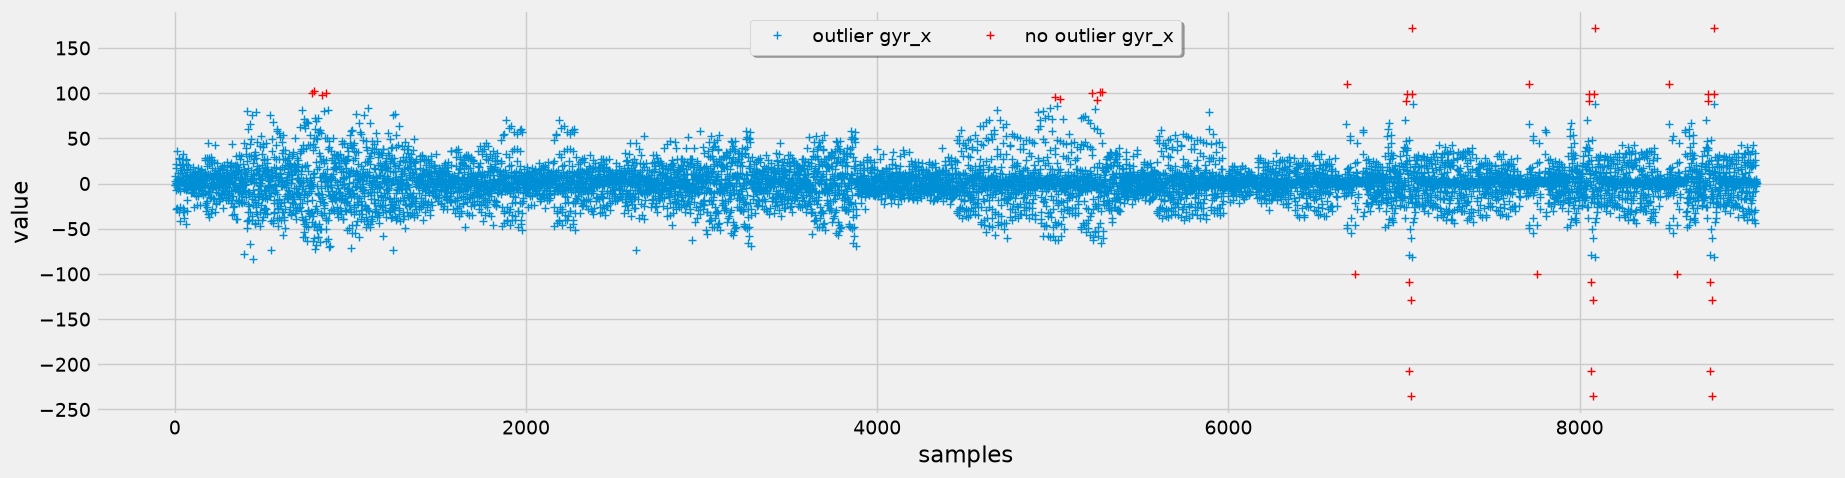

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


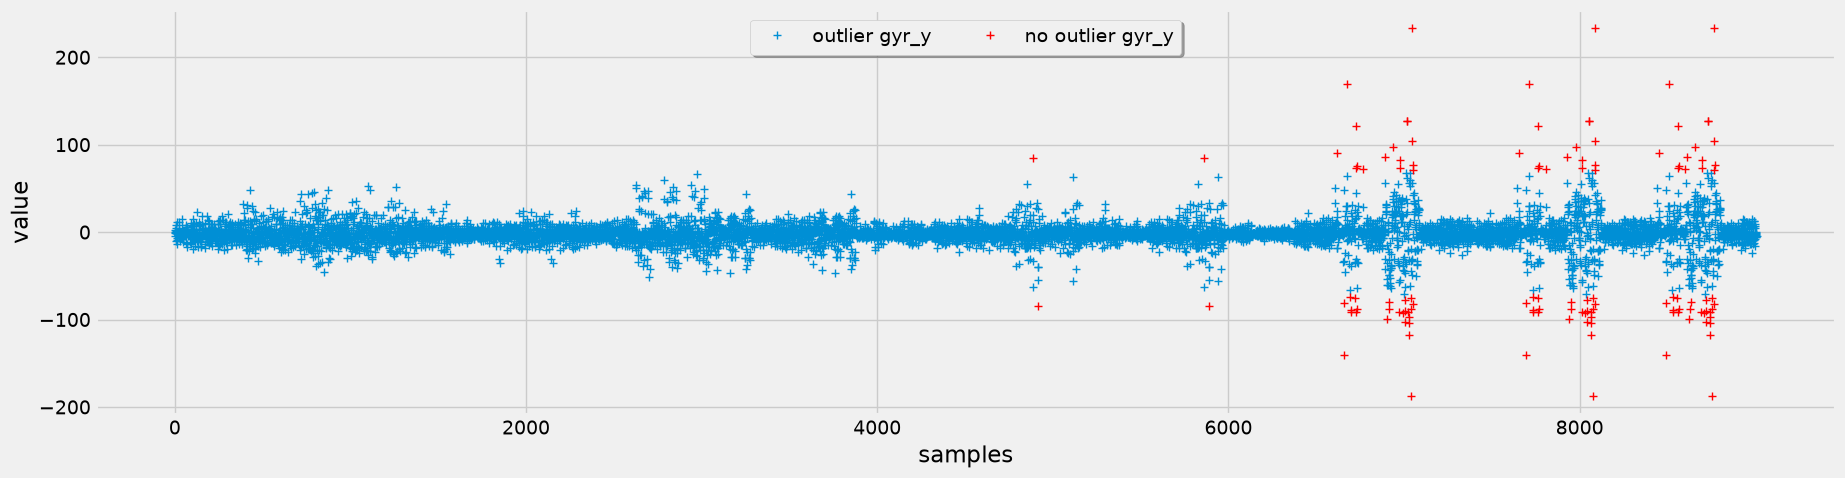

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


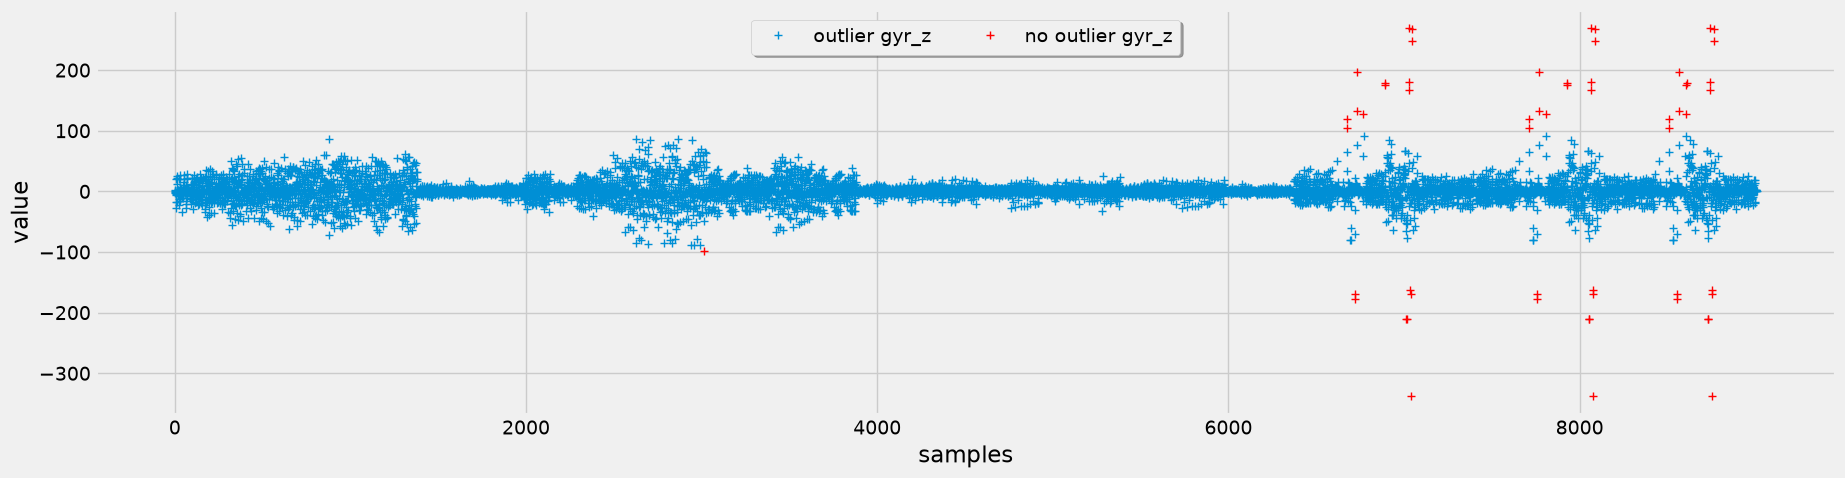

In [25]:
#Loop over all columns (Chauvenets Criteron)

for col in outliers_columns:
    dataset = mark_outliers_chauvenet(df,col)
    plot_binary_outliers(dataset=dataset, col=col, outlier_col=col+"_outlier", reset_index=True)

#### From the Above we have use the Chauvenets to determine the outliers, as the data we are working on has some very specific conditions.

- We were looking at the entire data in IQR method and the **rest** movements are diffrent for all paricipants
- The IRQ is variable distribution, it looks all the data and check the distribution
- In **Chauvenets** we are looking into the probility of the data with respect to entire data set also consider the individual Participansts.
- Here is the reason we are not getting outliers in second approch. It works only for some limited and specific conditions

## Local Outlier Factor

Unsupervised Outlier Detection using the Local Outlier Factor (LOF).

The anomaly score of each sample is called the Local Outlier Factor. It measures the local deviation of the density of a given sample with respect to its neighbors. It is local in that the anomaly score depends on how isolated the object is with respect to the surrounding neighborhood. More precisely, locality is given by k-nearest neighbors, whose distance is used to estimate the local density. By comparing the local density of a sample to the local densities of its neighbors, one can identify samples that have a substantially lower density than their neighbors. These are considered outliers.

In [29]:
#Local Outlier Factor Functions
def mark_outliers_lof(dataset, columns, n=20):
    """Mark values as outliers using LOF

    Args:
        dataset (pd.DataFrame): The dataset
        col (string): The column you want apply outlier detection to
        n (int, optional): n_neighbors. Defaults to 20.
    
    Returns:
        pd.DataFrame: The original dataframe with an extra boolean column
        indicating whether the value is an outlier or not.
    """
    
    dataset = dataset.copy()

    lof = LocalOutlierFactor(n_neighbors=n)
    data = dataset[columns]
    outliers = lof.fit_predict(data)
    X_scores = lof.negative_outlier_factor_

    dataset["outlier_lof"] = outliers == -1
    return dataset, outliers, X_scores

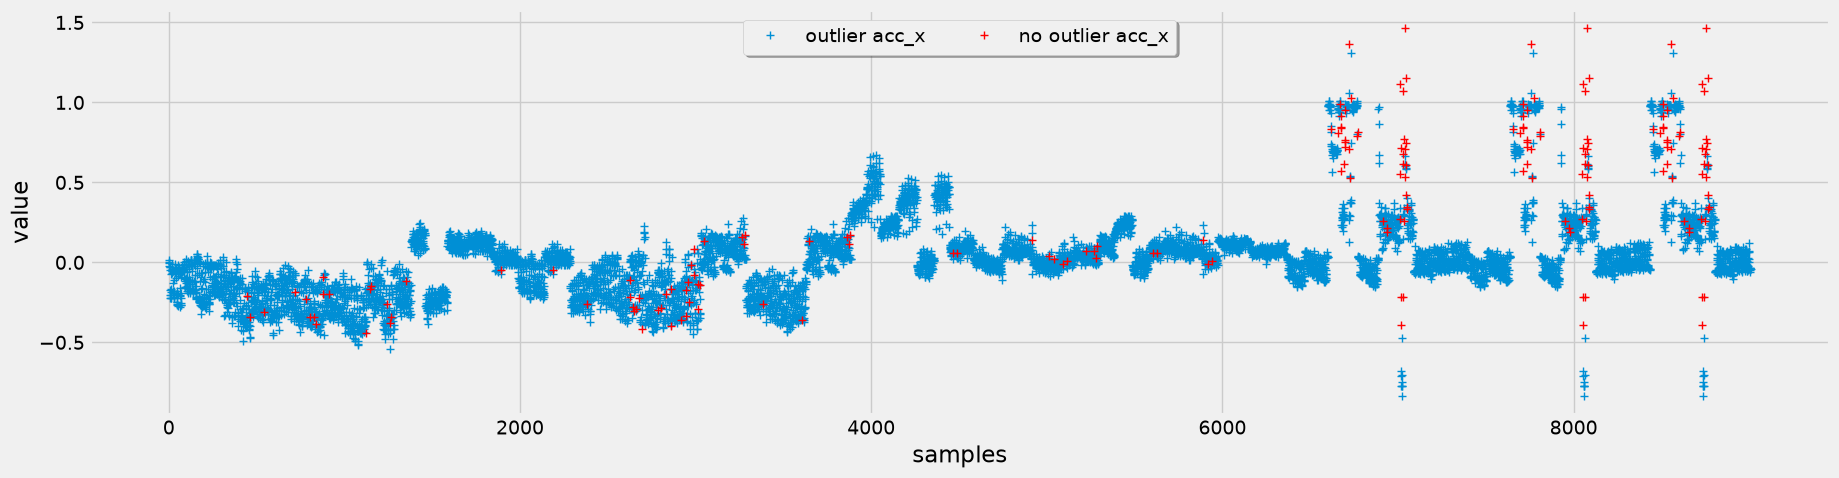

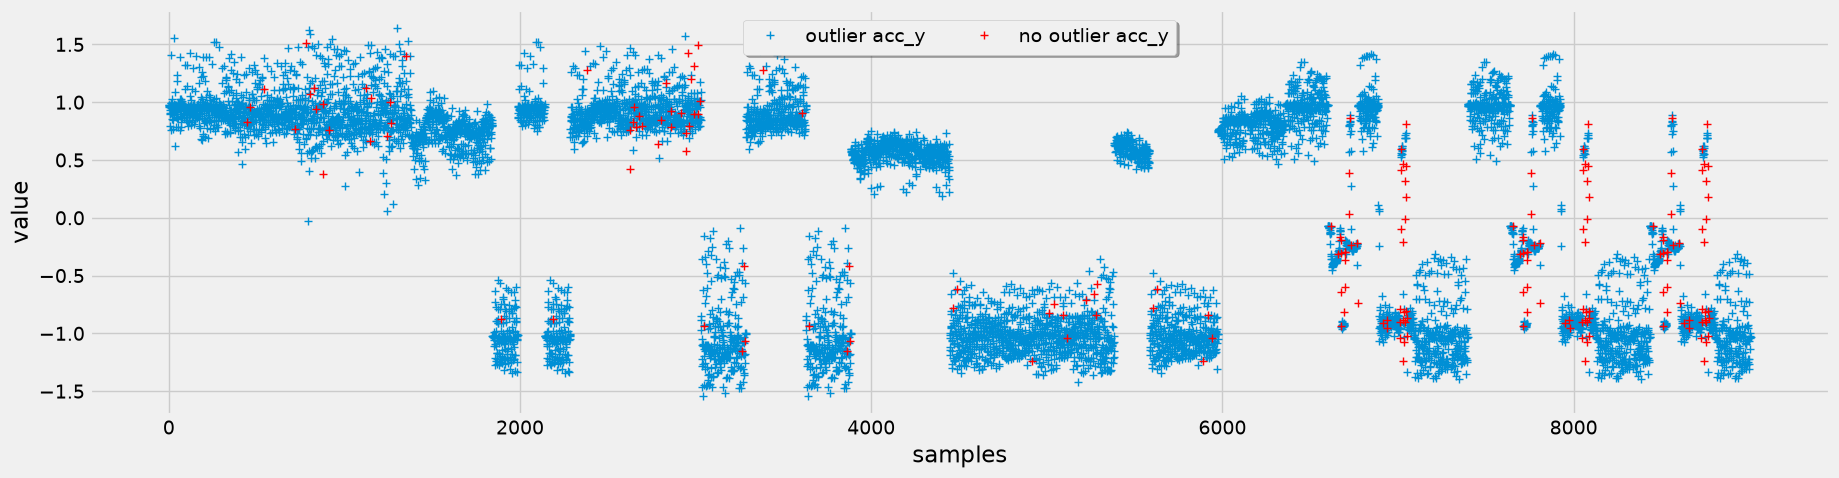

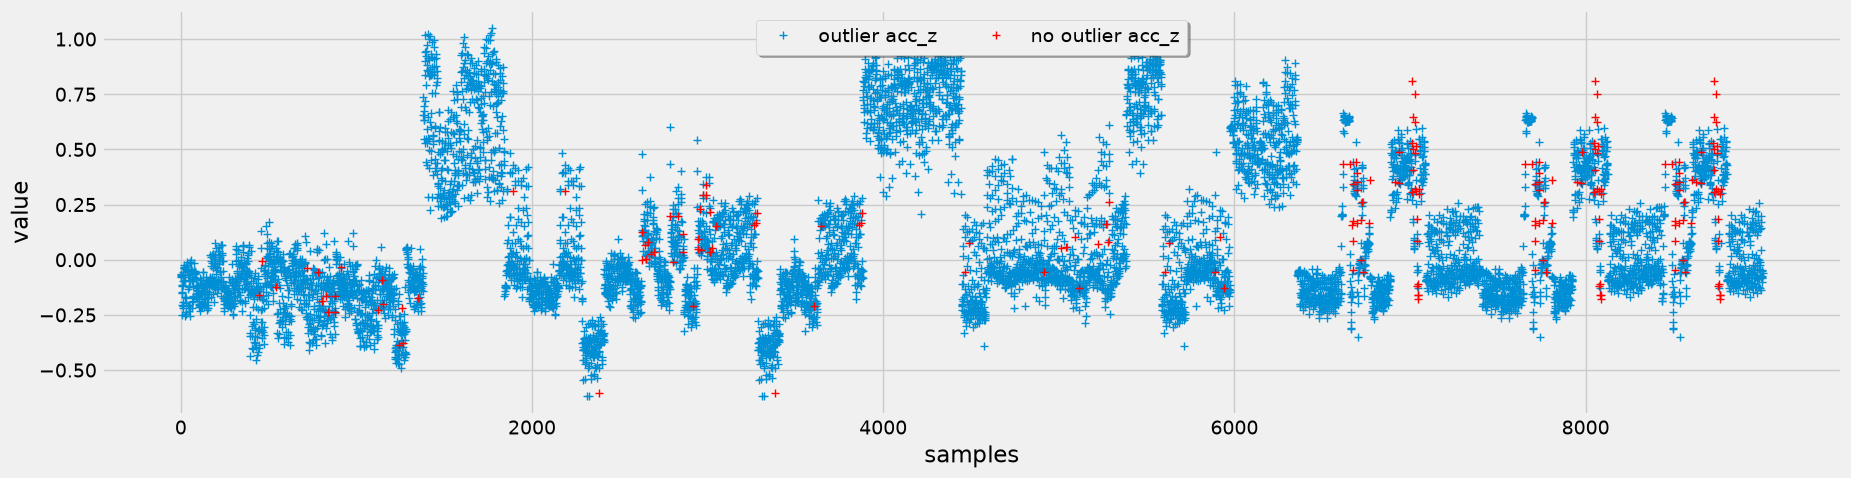

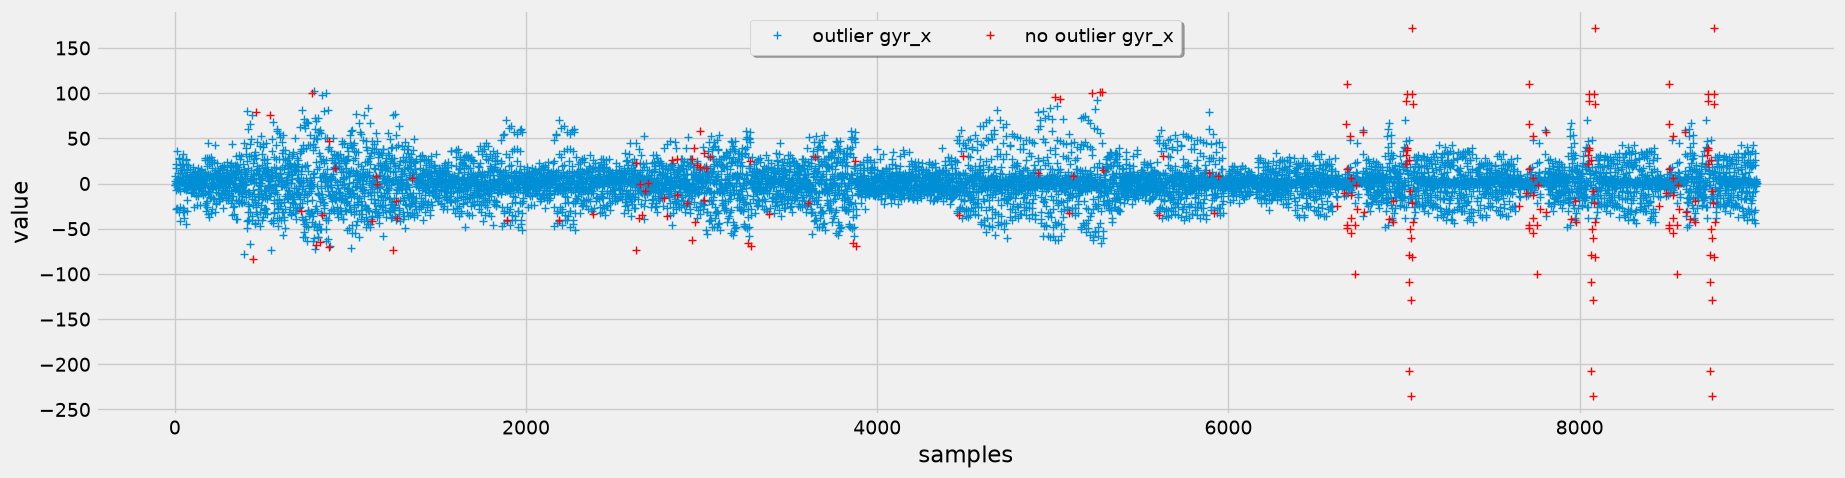

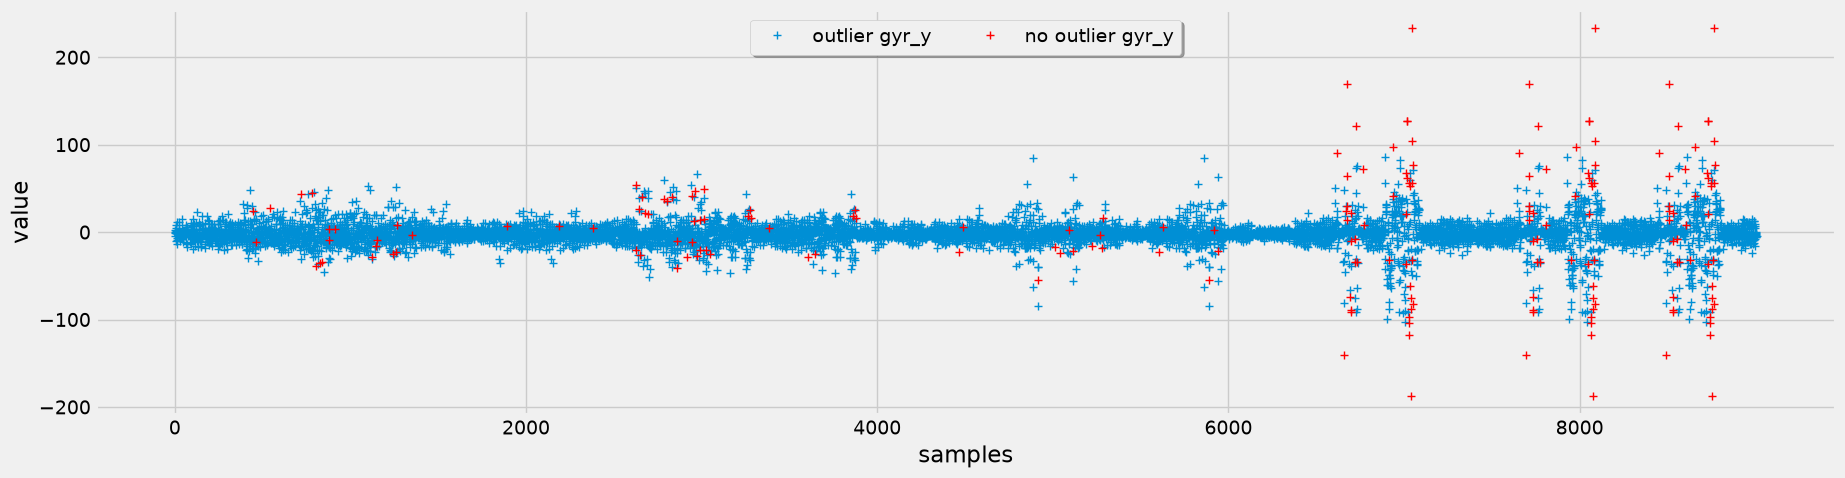

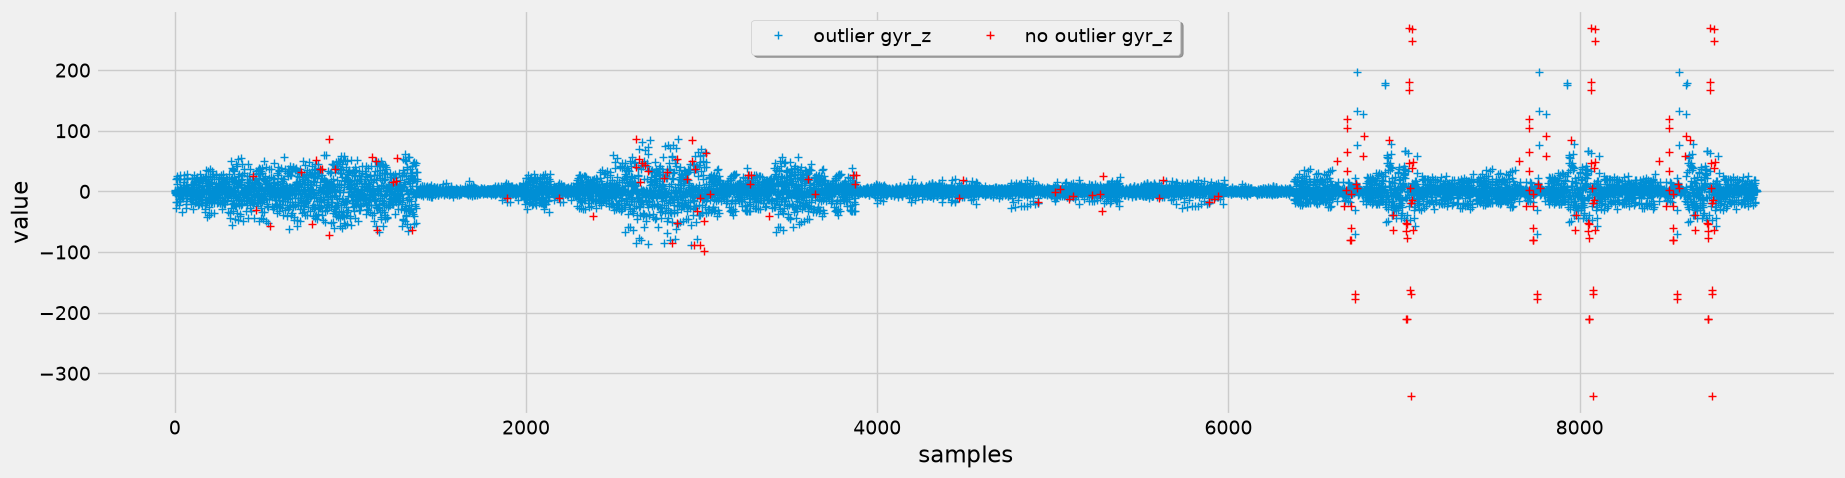

In [33]:
dataset, outliers, X_scores = mark_outliers_lof(df, outliers_columns)
for col in outliers_columns:
    plot_binary_outliers(dataset=dataset, col=col, outlier_col ="outlier_lof", reset_index= True)

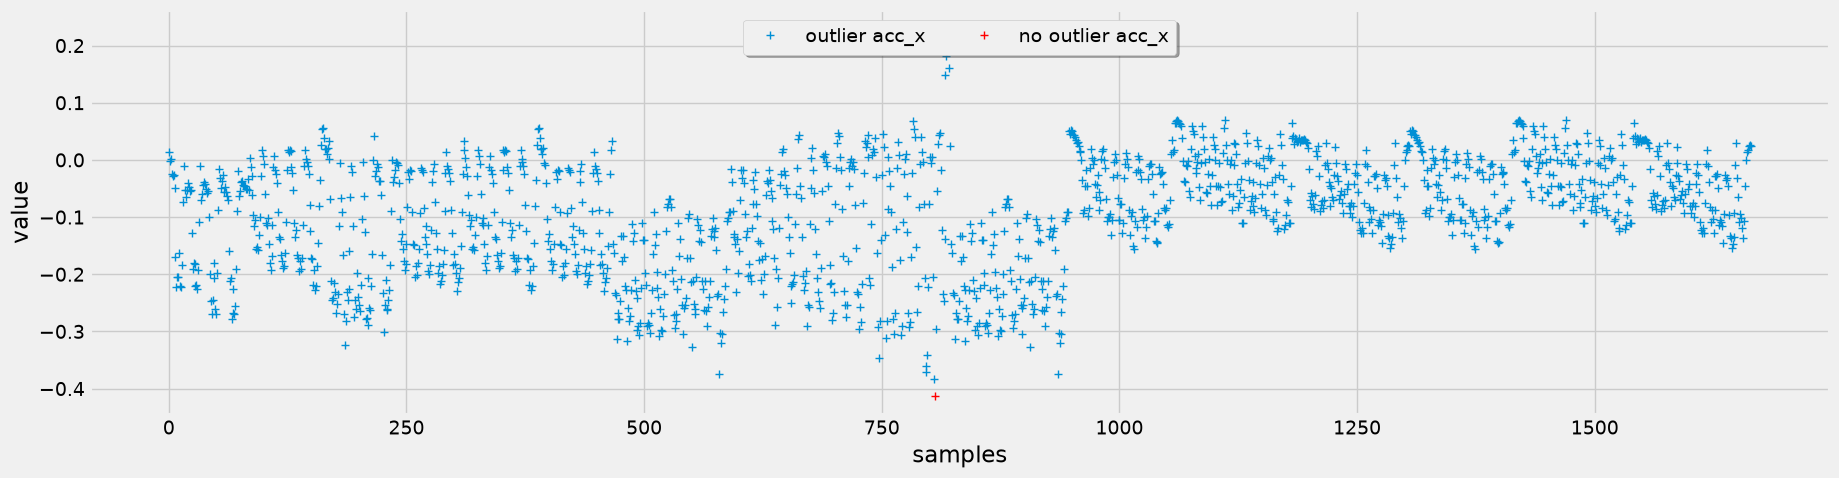

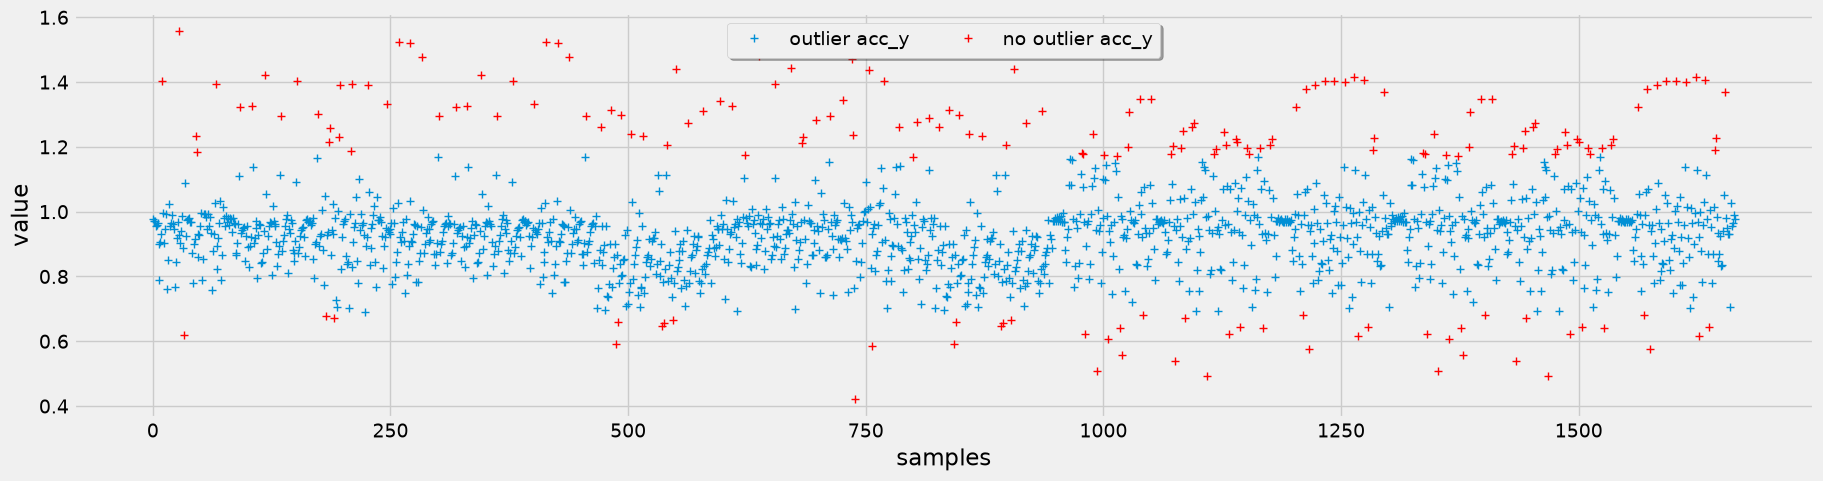

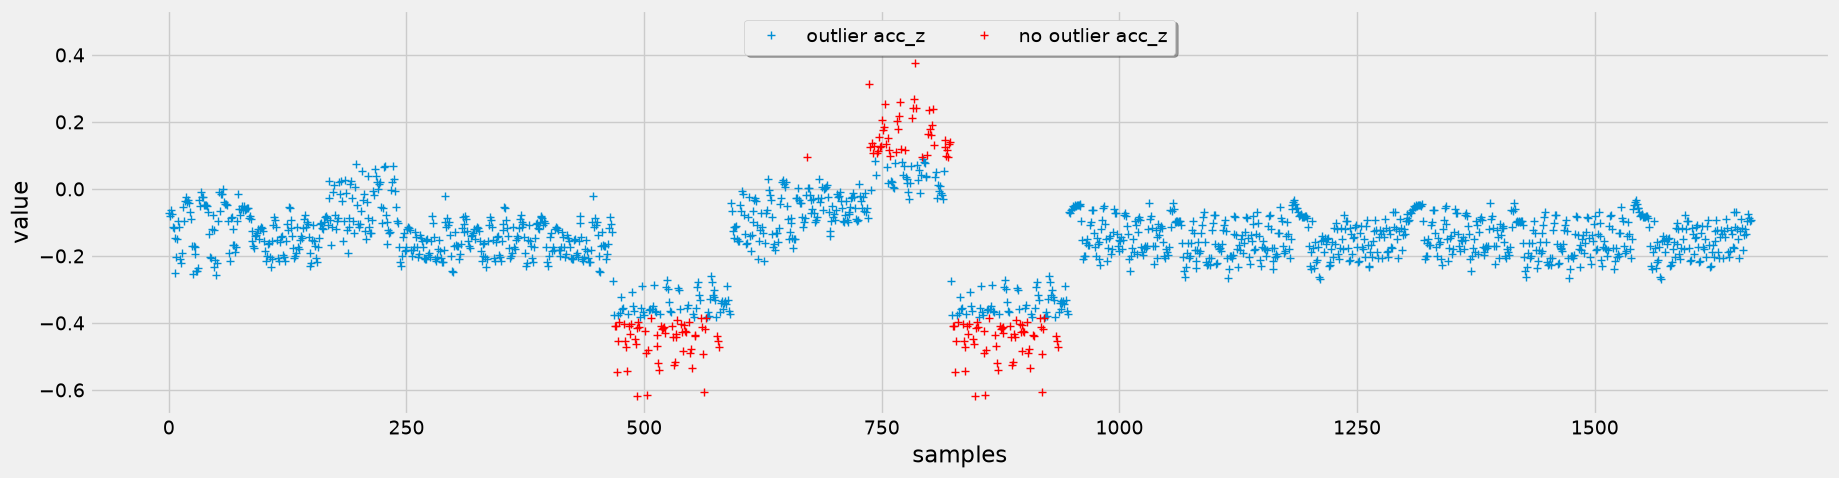

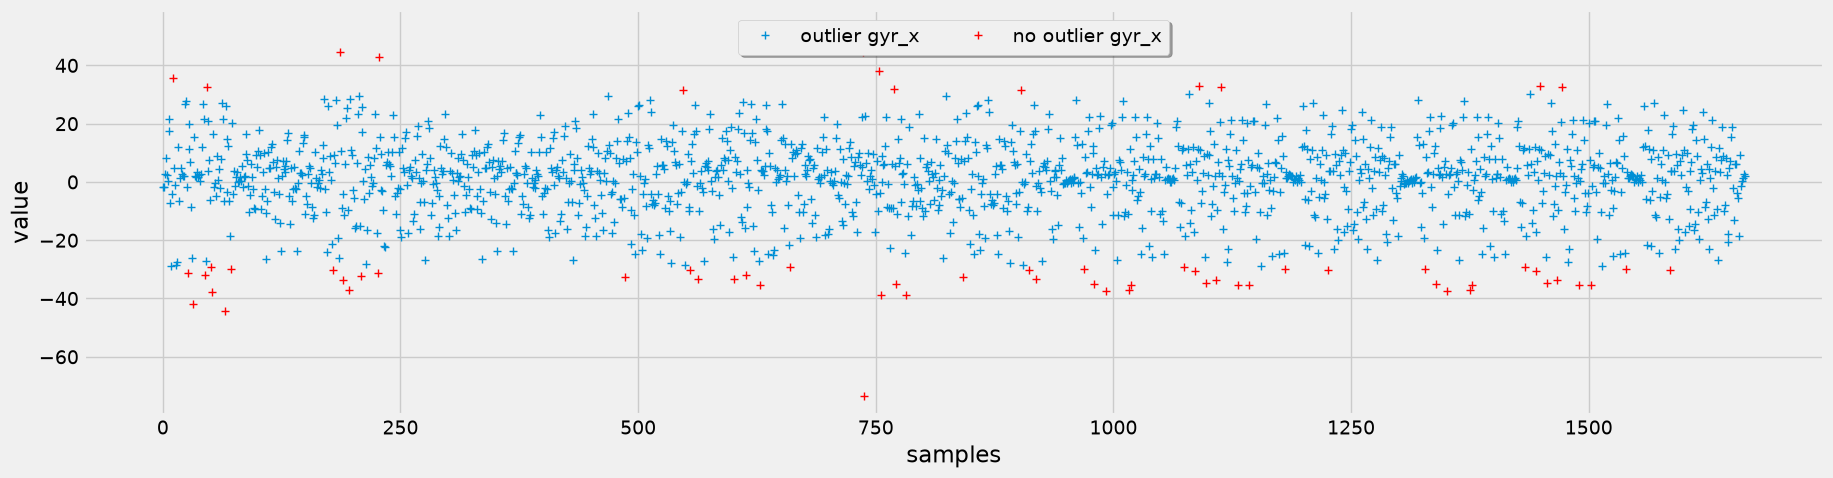

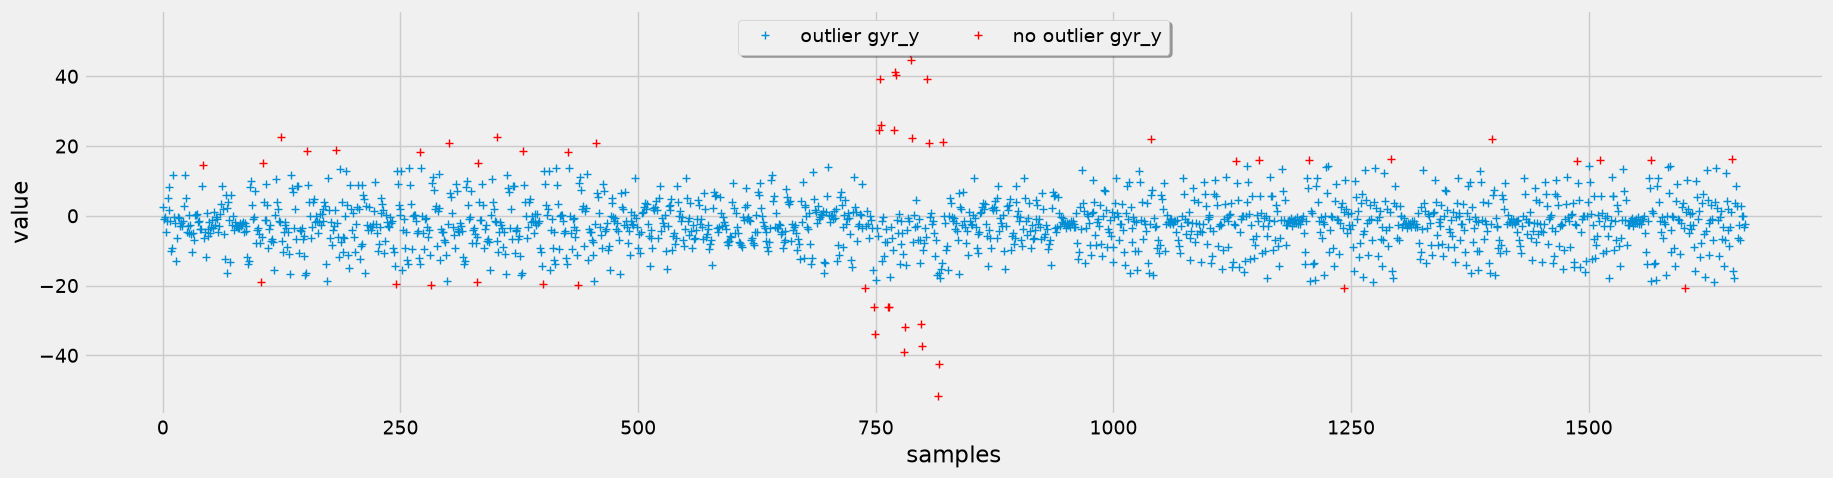

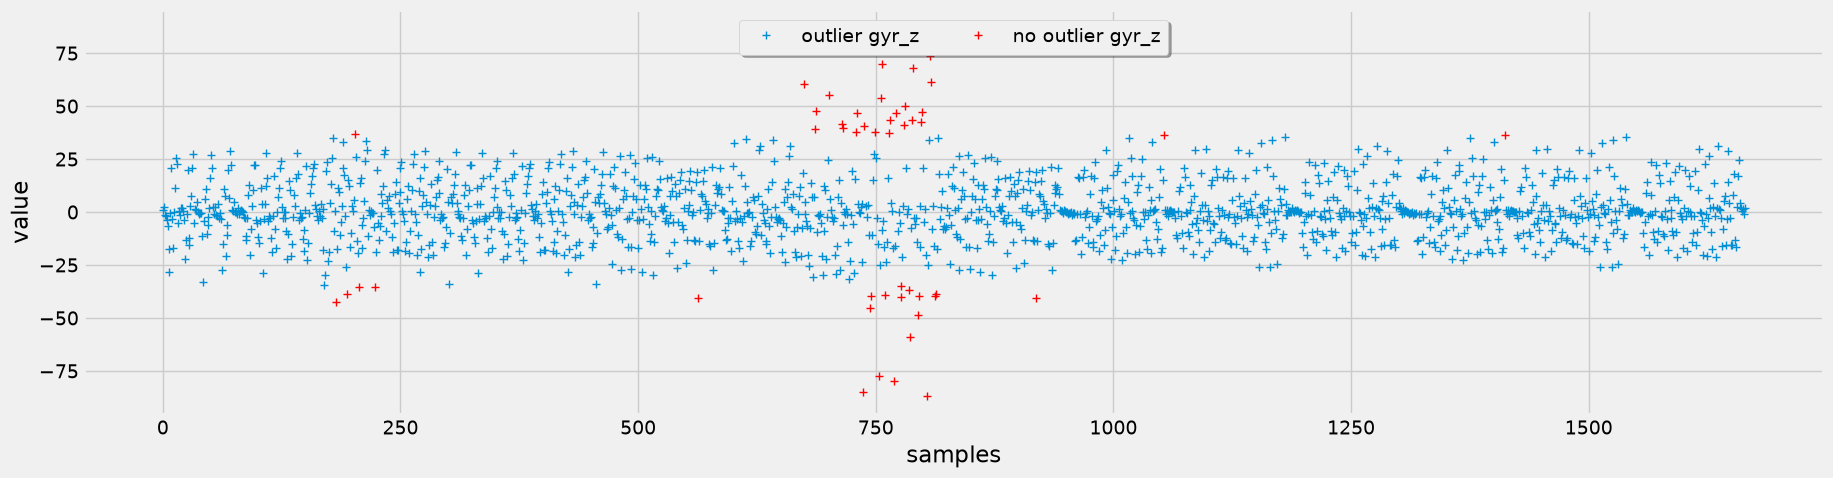

In [37]:
##Cheking outliers grouped by label

#using IQR method
label = "bench"
for col in outliers_columns:
    dataset = mark_outliers_iqr(df[df['label']==label], col) # Specific Data with bench data only
    plot_binary_outliers(dataset=dataset, col=col, outlier_col=col+"_outlier", reset_index=True)


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


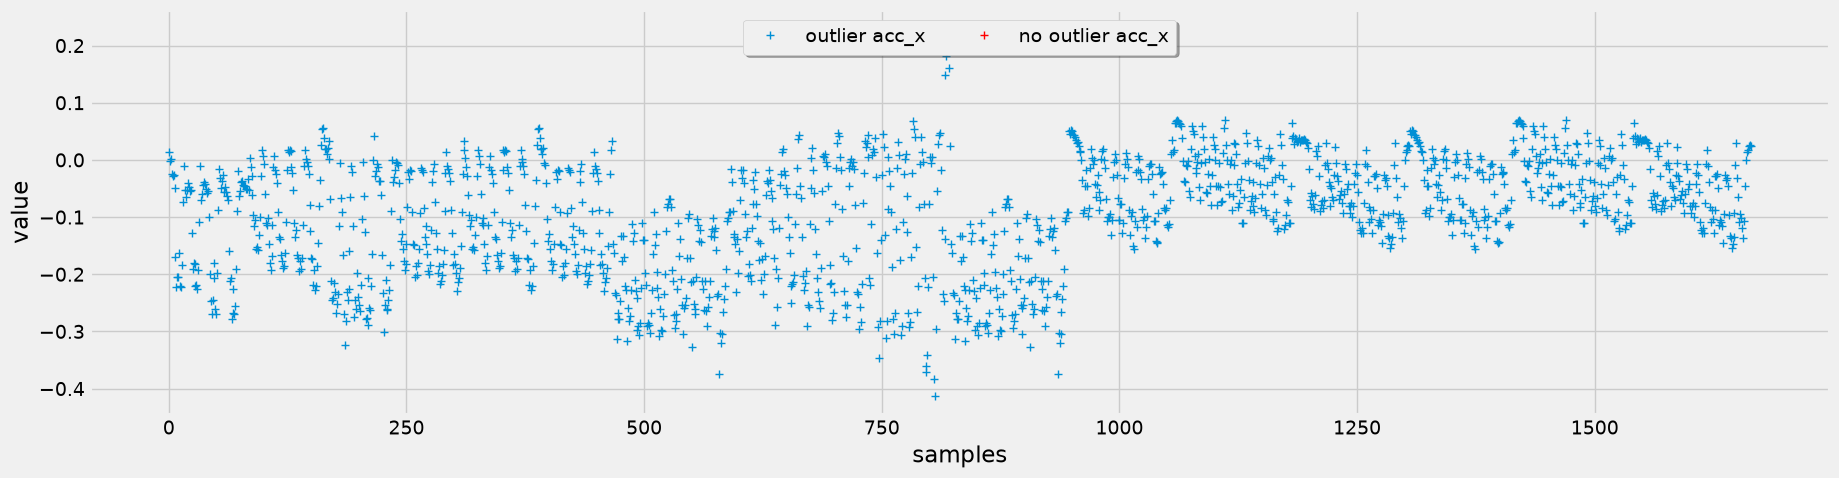

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


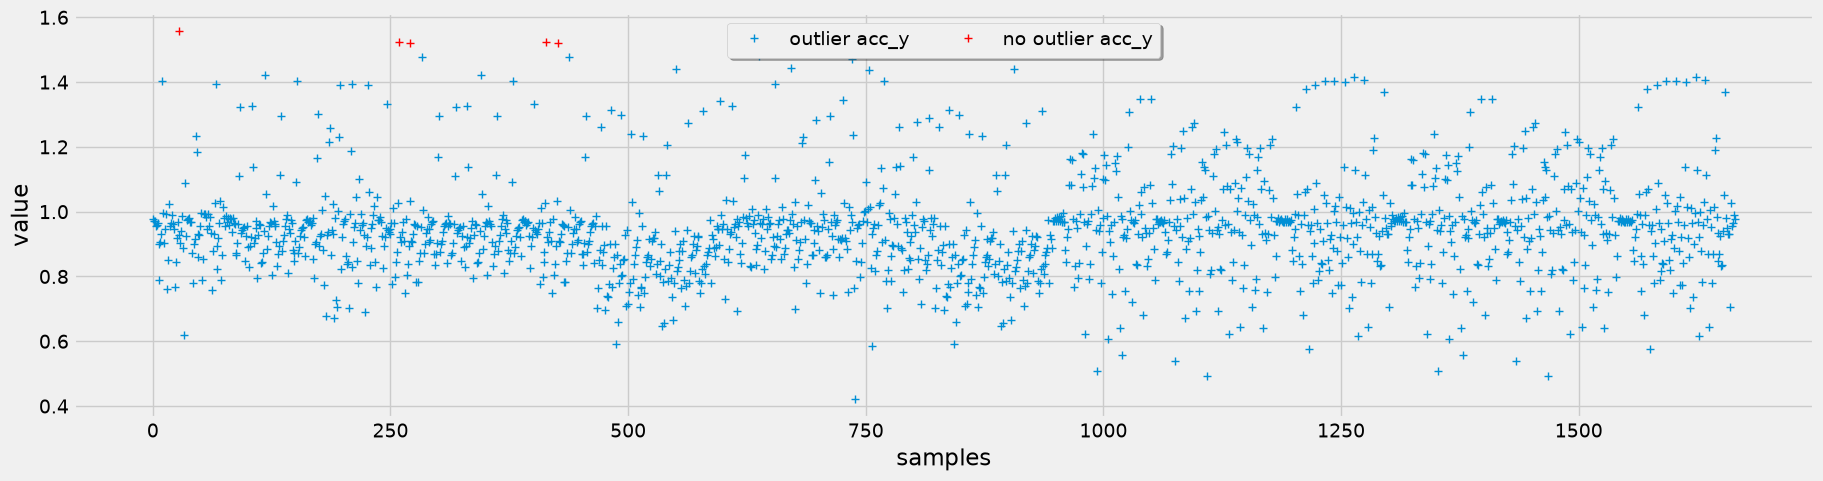

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


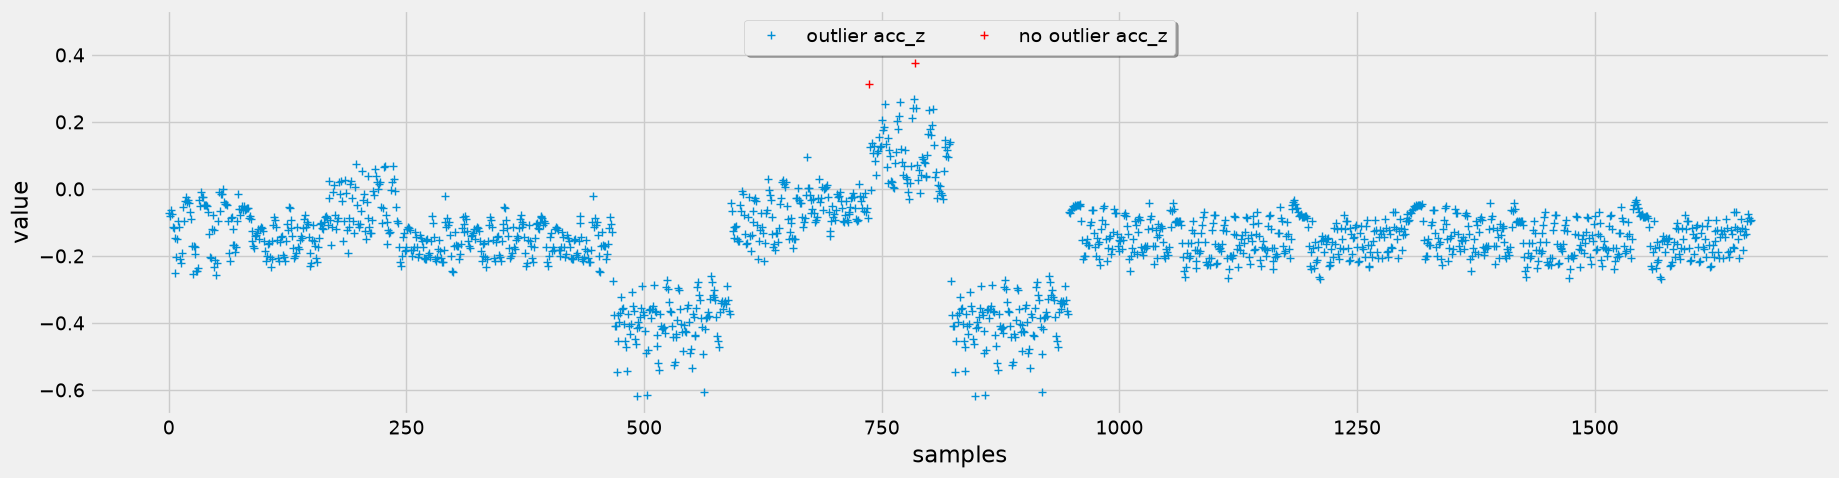

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


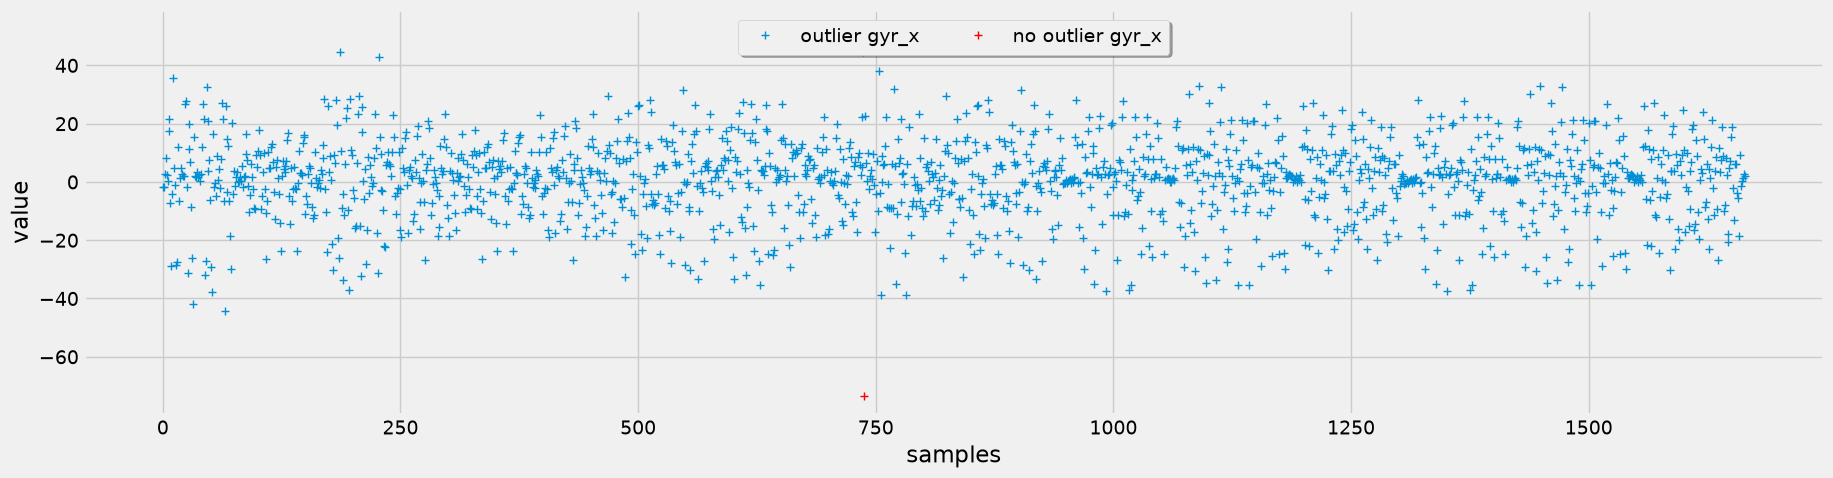

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


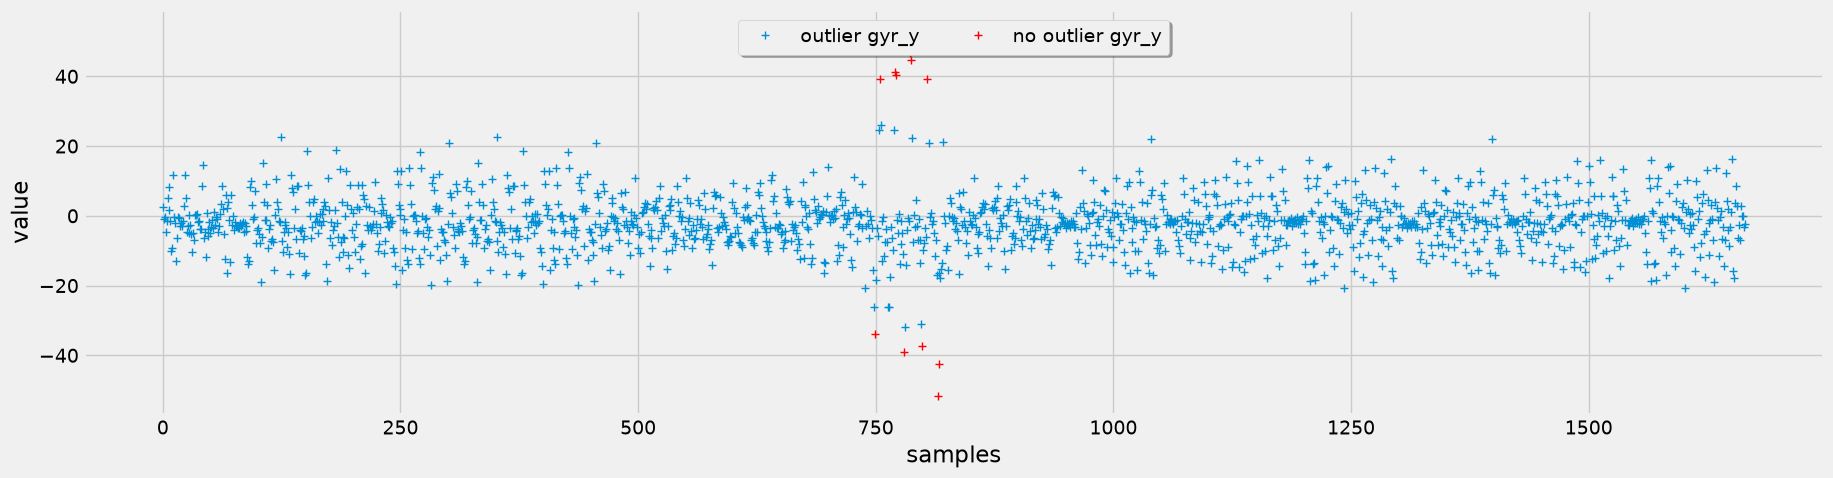

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


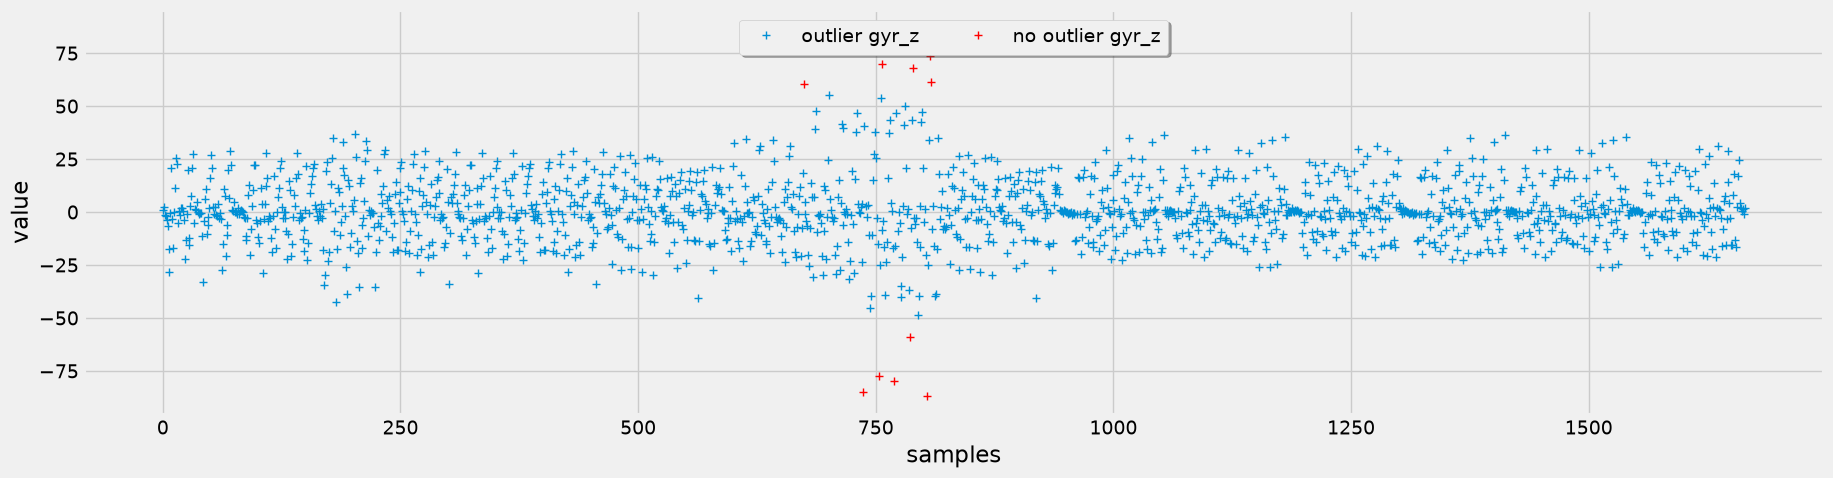

In [39]:
#using chauvenet method
label = "bench"
for col in outliers_columns:
    dataset = mark_outliers_chauvenet(df[df['label']==label], col) # Specific Data with bench data only
    plot_binary_outliers(dataset=dataset, col=col, outlier_col=col+"_outlier", reset_index=True)

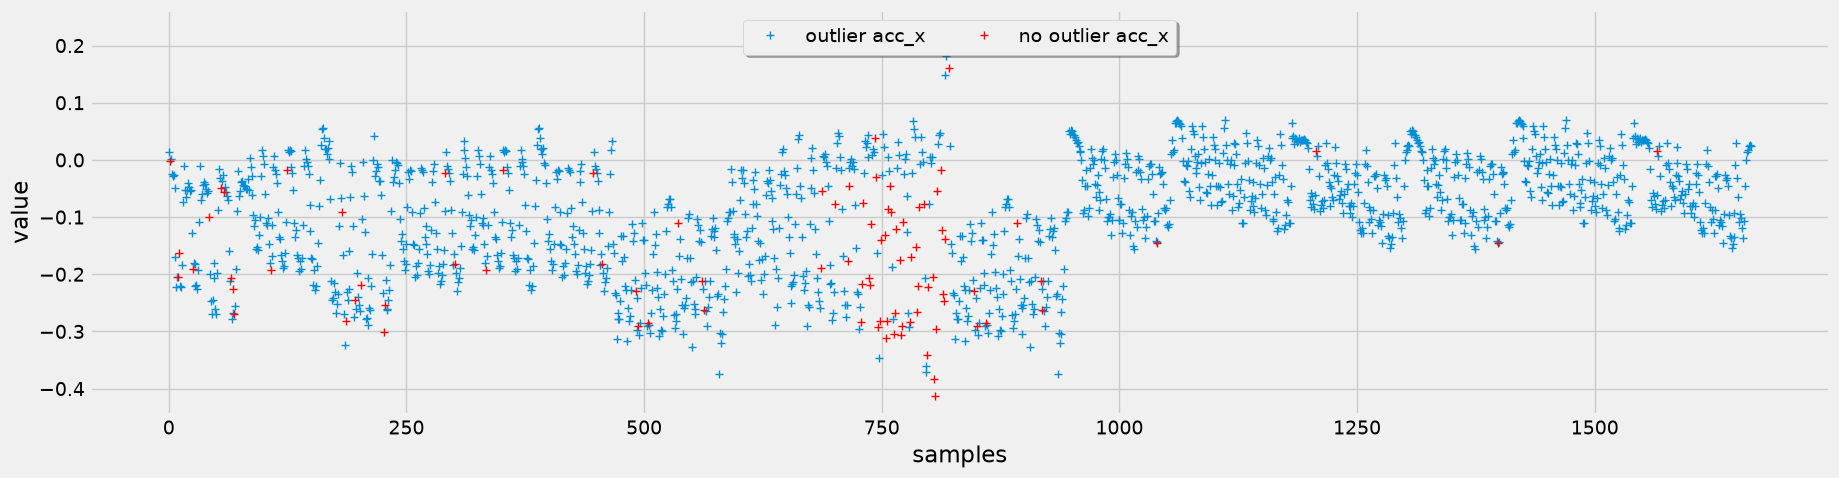

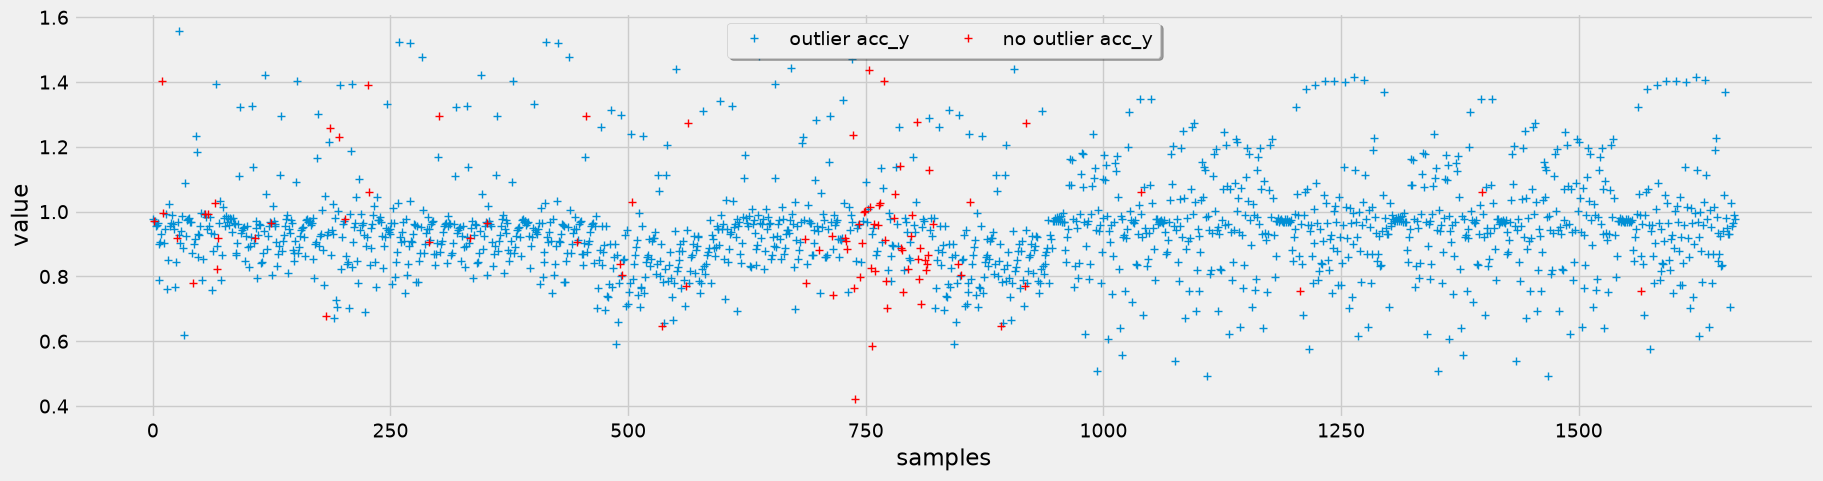

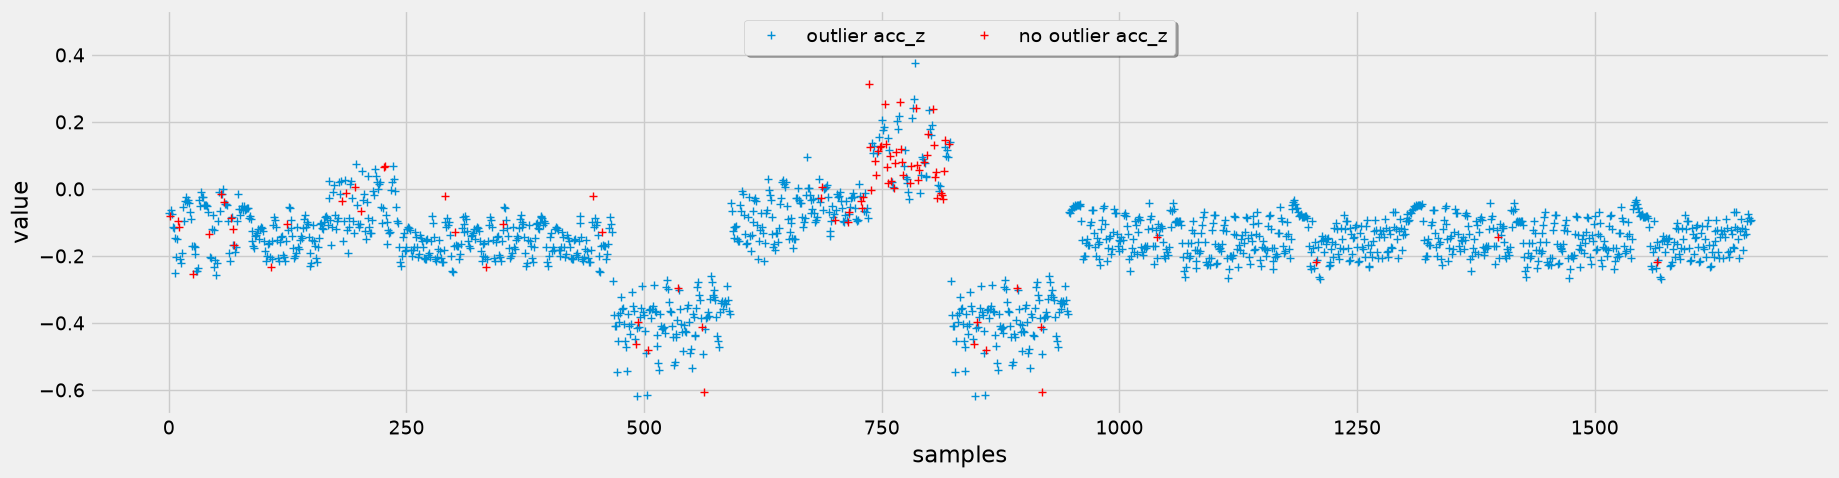

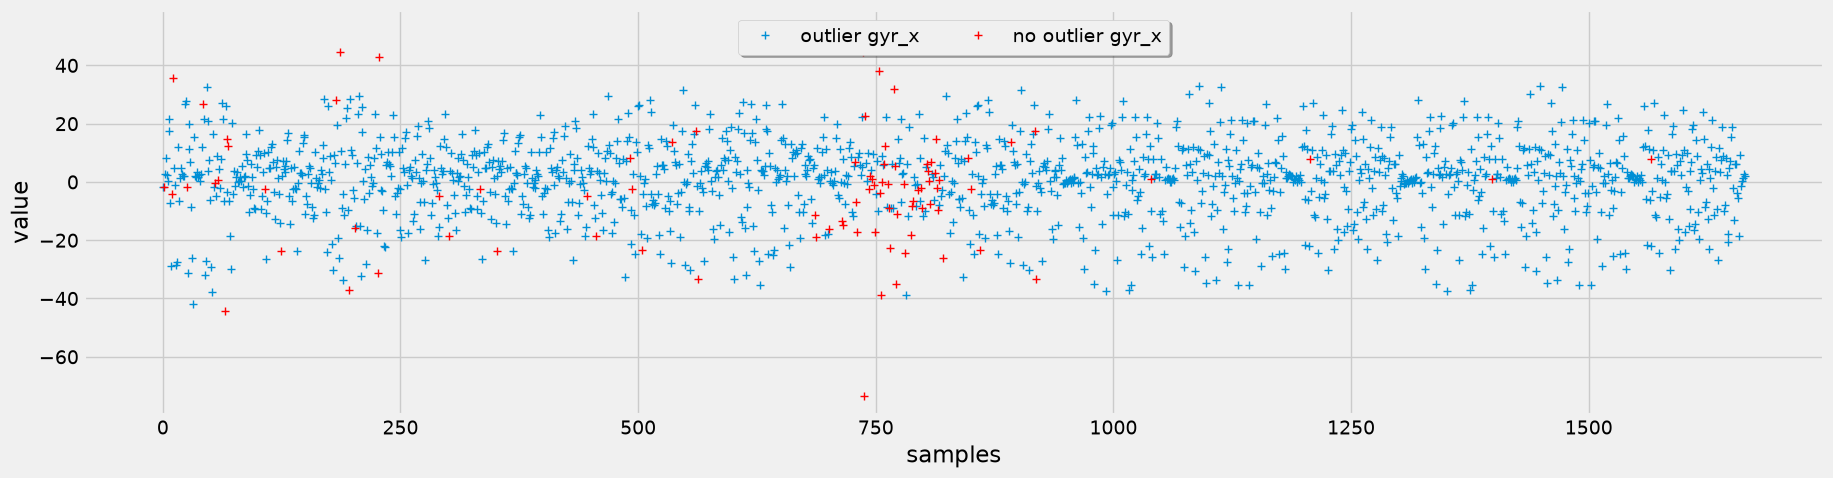

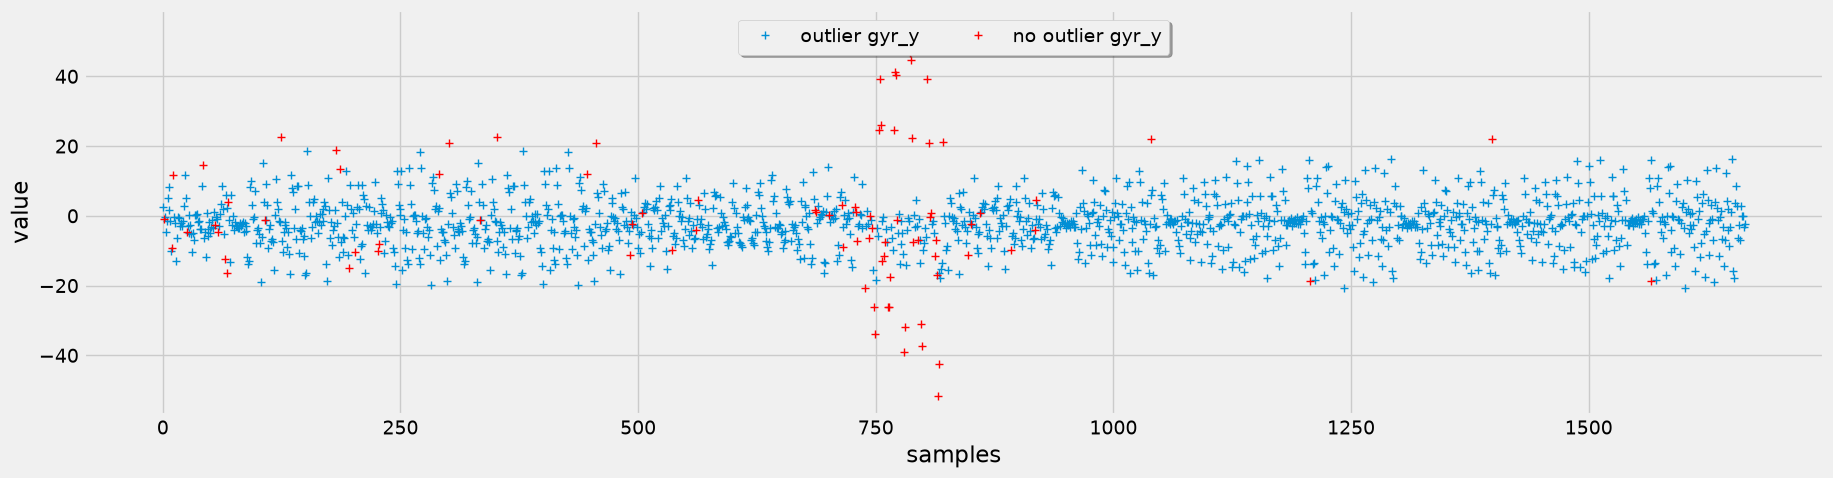

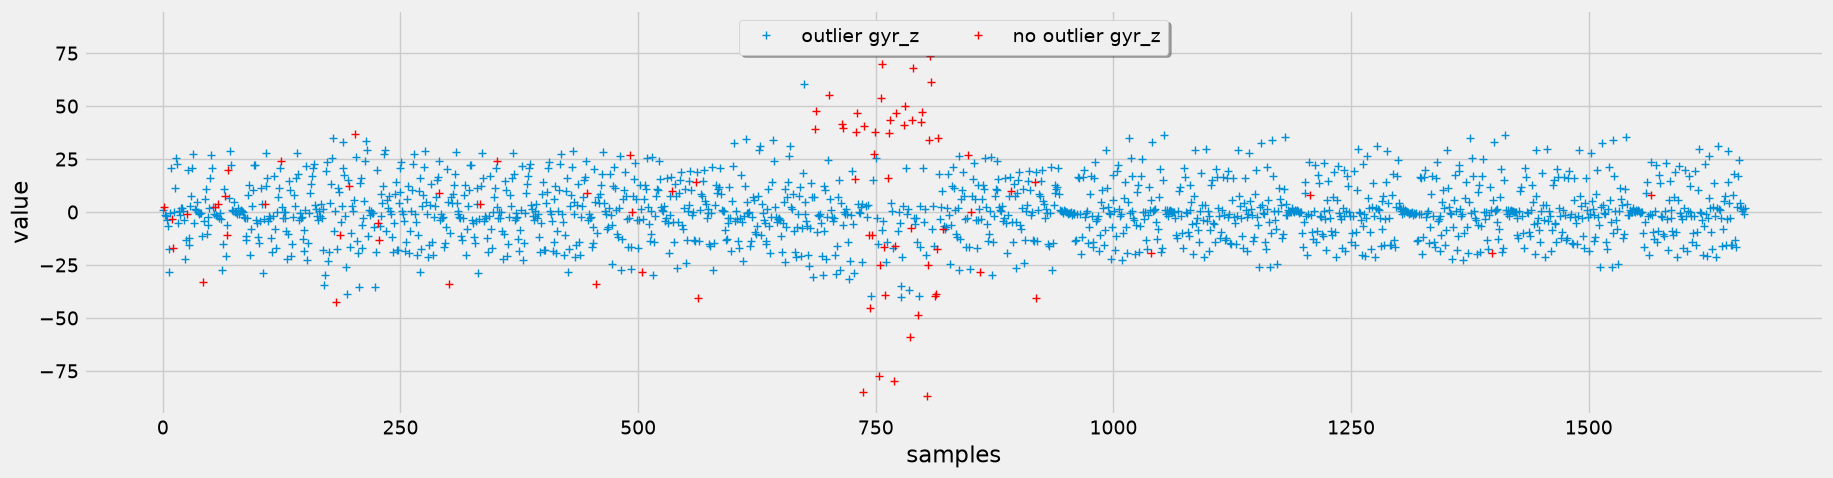

In [40]:
#using Local Outlier Factor method
label = "bench"
dataset, outliers, X_scores = mark_outliers_lof(df[df['label']==label], outliers_columns)
for col in outliers_columns:
    plot_binary_outliers(dataset=dataset, col=col, outlier_col ="outlier_lof", reset_index= True)

## Choosing the method and deal with outliers

In [53]:
# try on a single colmn
col = "gyr_z"
dataset = mark_outliers_chauvenet(df, col=col)
dataset[dataset['gyr_z_outlier']] # gets only the true value

dataset.loc[dataset[f"{col}_outlier"], col] = np.nan

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


In [54]:
# Creating a Loop for all colomns

outlier_reomved_df = df.copy()

for col in outliers_columns:
    for label in df['label'].unique():
        dataset = mark_outliers_chauvenet(df[df['label']==label], col)

        #remove values marked as outliers with NaN
        dataset.loc[dataset[f"{col}_outlier"], col] = np.nan

        #update the colomns in orginal datafram
        outlier_reomved_df.loc[(outlier_reomved_df['label']==label), col] = dataset[col]

        #checking if the fucntion is working as required so we give print statement
        n_outliers = len(dataset) - len(dataset[col].dropna())
        print(f"Removed {n_outliers} from {col} from {label}")


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


Removed 0 from acc_x from bench
Removed 2 from acc_x from ohp


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


Removed 0 from acc_x from squat
Removed 2 from acc_x from dead


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


...

/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))


Removed 10 from gyr_y from row
Removed 9 from gyr_y from rest
Removed 13 from gyr_z from bench
Removed 1 from gyr_z from ohp


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - s

Removed 12 from gyr_z from squat
Removed 14 from gyr_z from dead
Removed 0 from gyr_z from row
Removed 24 from gyr_z from rest


/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - scipy.special.erf(low[i]))
/tmp/ipykernel_10596/2008866811.py:40: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  1.0 - 0.5 * (scipy.special.erf(high[i]) - s

In [56]:
outlier_reomved_df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9009 entries, 2019-01-11 15:08:05.200000 to 2019-01-20 17:33:27.800000
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   acc_x         9005 non-null   float64
 1   acc_y         8998 non-null   float64
 2   acc_z         8999 non-null   float64
 3   gyr_x         8984 non-null   float64
 4   gyr_y         8938 non-null   float64
 5   gyr_z         8945 non-null   float64
 6   participants  9009 non-null   object 
 7   label         9009 non-null   object 
 8   Category      9009 non-null   object 
 9   set           9009 non-null   int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 1.0+ MB


In [57]:
outlier_reomved_df.to_pickle("../../data/interim/02_outlier_reomved_df.pkl")